# Project Overview
This project investigates the social and behavioral factors associated with Actual Usage Behavior (AUB) in social commerce among Generation Z university students in Vietnam. Using survey responses from 757 participants, the study examines how perceived ease of use, perceived usefulness, familiarity with social commerce, social participation, trust in platforms, and purchase intention relate to actual engagement with social commerce platforms. The project aims to uncover meaningful patterns among users and provide insights into the factors associated with social commerce adoption and usage among young consumers.


## **CBADVAI Phase 1: Dataset Exploration**

The first phase of the case study involves four sections – (1) dataset description, (2) data cleaning, (3) Exploratory Data Analysis, and (4) research question.

### [1] Dataset Description

The dataset was built using an online survey administered by a research team from the Industrial University of Ho Chi Minh City and Thai Nguyen University of Economics & Business Administration. This survey took approximately 15-20 minutes to complete, and participation was completely voluntary. Respondents between 18 and 27 years old were chosen.

Because the survey strictly filtered respondents to be of age 18 to 27, the results, analysis, insights, and conclusions cannot be generalized to that of the whole population, primarily because this demographic only includes their generation.

The ZIP contains three files: CSV file containing all survey responses, docx file of the survey questionnaire, and an Excel file of the codebook containing variable definitions. Since the CSV file already contains all survey responses in a single table, no merging of multiple datasets is required for the analysis. The questionnaire and codebook serve as supporting documentation.

The dataset is stored in a single CSV file. It contains survey responses collected from the chosen respondemts regarding their social commerce (S-commerce) usage behavior. Each row corresponds to one respondent, while each column corresponds to a demographic characteristic or a survey item measuring a specific construct related to social commerce adoption and usage (such as perceived usefulness, trust, familiarity, interaction behavior, and actual usage behavior).



In [ ]:
# Code explanation: Import the libraries needed to be used.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

import os
import sys

sys.path.append(os.path.abspath(".."))

# sets the theme of the charts
plt.style.use('seaborn-v0_8-darkgrid')

%matplotlib inline

In [ ]:
# The dataset is first loaded into a dataframe using `pandas`.
from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/CBADVAI-CBDATSI-CBSWEG2')
sys.path.append('/content/drive/MyDrive/CBADVAI-CBDATSI-CBSWEG2')

# Import preprocessing wrapper functions
from Scripts.preprocessing import (
    load_dataset,
    inspect_dataset,
    validate_columns,
    validate_dtypes,
    drop_columns,
    check_missing_values,
    find_duplicates,
    validate_unique_values,
    compute_composite_score,
)

scommerce_df = pd.read_csv(
    '/content/drive/MyDrive/CBADVAI-CBDATSI-CBSWEG2/Notebooks/S-COMMERCE_GenZ_UniversityStudent_757_DIB_copy.csv'
)

Mounted at /content/drive


The dataset contains 757 observations (rows), 30 variables (columns).

In [ ]:
rows, columns = inspect_dataset(scommerce_df)

print(f"Rows (observations): {rows}")
print(f"Columns (variables): {columns}")

Rows (observations): 757
Columns (variables): 31


The dataset contains demographic variables (Gender, Income, Area, Frequently) and survey construct variables measuring Perceived Usefulness (PU), Perceived Ease of Use (PEU), Familiarity with Social Commerce (FSC), Social Presence (SP), Trust in Platform (TP), Interaction Behavior (IB), and Actual Usage Behavior (AUB).

In [ ]:
validate_columns(scommerce_df)

['Gender',
 'Job',
 'Income',
 'Area',
 'Frequently',
 'PU1',
 'PU2',
 'PU3',
 'PU4',
 'PEU1',
 'PEU2',
 'PEU3',
 'PEU4',
 'FSC1',
 'FSC2',
 'FSC3',
 'SP1',
 'SP2',
 'SP3',
 'SP4',
 'TP1',
 'TP2',
 'TP3',
 'IB1',
 'IB2',
 'IB3',
 'IB4',
 'AUB1',
 'AUB2',
 'AUB3',
 'AUB4']

The `Gender` variable contains 3 unique values.
* 1 - Male
* 2 - Female
* 3 - Different

In [ ]:
scommerce_df['Gender'].value_counts().sort_index()

,count
Gender,
1,167
2,588
3,2


The `Income` variable contains 5 unique values.
* 1 - less than 100 USD
* 2 - from 100 USD to less than 200 USD
* 3 - from 200 USD to less than 300 USD
* 4 - from 300 USD to less than 400 USD
* 5 - above 400 USD

In [ ]:
scommerce_df['Income'].value_counts().sort_index()

,count
Income,
1,672
2,68
3,12
4,2
5,3


The `Area` variable contains 3 unique values.
* 1 - Urban
* 2 - Suburban
* 3 - Rural

In [ ]:
scommerce_df['Area'].value_counts().sort_index()

,count
Area,
1,461
2,74
3,222


The `Frequently` variable contains 4 unique values.
* 1 - Daily
* 2 - Weekly
* 3 - Monthly
* 4 - Rarely Used

In [ ]:
scommerce_df['Frequently'].value_counts().sort_index()

,count
Frequently,
1,725
2,14
3,7
4,11


#### For the following survey variables, they use the following scale:
* 1 - Strongly disagree,
* 2 - Disagree
* 3 - Neutral
* 4 - Agree
* 5 - Strongly agree

#### Perceived Usefulness (PU)
Measure the extent to which respondents believe social commerce improves their shopping effectiveness and productivity.
* `PU1`: Using social commerce platforms improves online shopping performance.
* `PU2`: Using social commerce platforms increases productivity in finding products.
* `PU3`: Using social commerce platforms enhances effectiveness when making online purchases.
* `PU4`: Social commerce platforms are useful for online transactions.

In [ ]:
scommerce_df[['PU1','PU2','PU3','PU4']].head()

,PU1,PU2,PU3,PU4
0,4,4,4,4
1,3,3,3,3
2,3,3,3,3
3,5,5,5,5
4,4,4,4,4



#### Perceived Ease of Use (PEU)
Measure how easy respondents find social commerce platforms to use.
* `PEU1`: Interaction with social commerce platforms is clear and understandable.
* `PEU2`: Using social commerce platforms requires little mental effort.
* `PEU3`: It is easy to make social commerce platforms perform desired tasks.



In [ ]:
scommerce_df[['PEU1','PEU2','PEU3']].head()

,PEU1,PEU2,PEU3
0,4,4,4
1,3,3,3
2,3,3,3
3,5,5,5
4,4,4,4


However, the CSV file contains a variable `PEU4` that is not documented in the codebook, questionnaire, and its research paper.

In [ ]:
scommerce_df['PEU4'].head()

,PEU4
0,4
1,3
2,3
3,5
4,4


Since `PEU4` is not defined in the codebook or questionnaire, its meaning cannot be accurately determined. Therefore, the variable will be removed during data cleaning to maintain data consistency and interpretability throughout the analysis.

#### Familiarity with Social Commerce (FSC)
Measure respondents' familiarity with social commerce platforms.
* `FSC1`: Familiarity gained through personal experience using social commerce platforms.
* `FSC2`: Familiarity gained through reading news, blogs, and related materials.
* `FSC3`: Familiarity gained through communication with others regarding social commerce.
* `FSC4`: Familiarity gained through discussions, reviews, and shared experiences.


In [ ]:
scommerce_df[['FSC1','FSC2','FSC3']].head()

,FSC1,FSC2,FSC3
0,4,4,4
1,3,3,3
2,3,3,3
3,5,5,5
4,3,3,3


As seen from the code block above, FSC4 is no longer called as it does not exist in the dataset. Even though it is defined in the codebook, questionnaire, and the study, since it does not appear in the CSV file of the dataset, calling it will only cause errors. Therefore, it is disregarded. Further explanation will be provided in the Data Cleaning section.


#### Social Presence (SP)
Measure the degree of social interaction experienced through social commerce platforms.
* `SP1`: Frequency of attending online group meetings or events through social commerce platforms.
* `SP2`: Frequency of socializing with friends through social commerce platforms.
* `SP3`: Frequency of socializing with relatives through social commerce platforms.
* `SP4`: General level of social interaction and engagement on social commerce platforms.

In [ ]:
scommerce_df[['SP1','SP2','SP3', 'SP4']].head()

,SP1,SP2,SP3,SP4
0,4,4,4,4
1,3,3,3,3
2,3,3,3,3
3,5,5,5,5
4,2,3,3,3



#### Trust in Platform (TP)
Measure respondents' trust in social commerce platforms.
* `TP1`: Social commerce platforms are competent and effective.
* `TP2`: Social commerce platforms act in users' best interests.
* `TP3`: Social commerce platforms can be trusted consistently.


In [ ]:
scommerce_df[['TP1','TP2','TP3']].head()

,TP1,TP2,TP3
0,4,4,4
1,3,3,3
2,3,3,3
3,5,5,5
4,3,3,3



#### Interaction Behavior (IB)
These variables measure respondents' willingness to interact and share information with others through social commerce platforms.
* `IB1`: Willingness to provide information to vendors.
* `IB2`: Willingness to share shopping experiences and suggestions with friends.
* `IB3`: Willingness to purchase products recommended by friends.
* `IB4`: Willingness to consider friends' shopping experiences when making purchases.

In [ ]:
scommerce_df[['IB1','IB2','IB3', 'IB4']].head()

,IB1,IB2,IB3,IB4
0,3,3,3,3
1,3,3,3,3
2,3,3,3,3
3,5,5,5,5
4,4,4,3,4


#### Actual Usage Behavior (AUB)
These variables measure respondents' actual usage of social commerce platforms.
* `AUB1`: Using social commerce platforms is enjoyable.
* `AUB2`: Uses social commerce platforms for safe online shopping.
* `AUB3`: Spends significant time on social commerce platforms.
* `AUB4`: Regularly uses social commerce platforms.

### [2] Data Cleaning
Before conducting the analysis, the dataset was inspected to identify potential data quality issues that could affect the validity and reliability of the results. This process involved examining the variables for missing values, duplicate records, incorrect data types, inconsistent formatting, invalid values, and other anomalies that may interfere with subsequent analyses. Approriate cleaning and processing were applied as necessary.

#### Variable Verification

Before any cleaning procedures were performed, the variables loaded from the dataset were examined against the questionnaire and accompanying study provided by the authors. This step was conducted to verify that all expected variables were successfully loaded and that each variable was properly documented and corresponded to the constructs described in the study to ensure consistency.

In [ ]:
scommerce_df.columns

Index(['Gender', 'Job', 'Income', 'Area', 'Frequently', 'PU1', 'PU2', 'PU3',
       'PU4', 'PEU1', 'PEU2', 'PEU3', 'PEU4', 'FSC1', 'FSC2', 'FSC3', 'SP1',
       'SP2', 'SP3', 'SP4', 'TP1', 'TP2', 'TP3', 'IB1', 'IB2', 'IB3', 'IB4',
       'AUB1', 'AUB2', 'AUB3', 'AUB4'],
      dtype='object')

As discussed in the Dataset Description section, the variable `PEU4` is not documented in the codebook, questionnaire, or the associated research paper. Since its meaning and purpose cannot be verified, the variable is removed from the dataset to avoid introducing ambiguity into the analysis.

In [ ]:
# Remove the PEU4 column
scommerce_df = drop_columns(
    scommerce_df,
    ["PEU4"]
)

# Verify removal
print(inspect_dataset(scommerce_df))
scommerce_df.head()

(757, 30)


,Gender,Job,Income,Area,Frequently,PU1,PU2,PU3,PU4,PEU1,...,TP2,TP3,IB1,IB2,IB3,IB4,AUB1,AUB2,AUB3,AUB4
0,2,1,1,1,1,4,4,4,4,4,...,4,4,3,3,3,3,4,4,4,4
1,2,1,1,1,1,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
2,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,4,2,4
3,1,1,1,3,1,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
4,2,1,1,3,1,4,4,4,4,4,...,3,3,4,4,3,4,3,3,3,3


The code above drops the `PEU4` column from the DataFrame and then displays the dataset's dimensions and a preview of the first few rows to confirm that the column has been successfully removed.

In [ ]:
scommerce_df.columns

Index(['Gender', 'Job', 'Income', 'Area', 'Frequently', 'PU1', 'PU2', 'PU3',
       'PU4', 'PEU1', 'PEU2', 'PEU3', 'FSC1', 'FSC2', 'FSC3', 'SP1', 'SP2',
       'SP3', 'SP4', 'TP1', 'TP2', 'TP3', 'IB1', 'IB2', 'IB3', 'IB4', 'AUB1',
       'AUB2', 'AUB3', 'AUB4'],
      dtype='object')

Based on the dataset columns displayed above, all expected variables from the questionnaire and supporting documentation were successfully loaded from the CSV file. However, an additional variable named Job was identified. This variable is not documented in the questionnaire, codebook, or accompanying research paper, nor is it utilized in the study. To determine whether the variable contains any meaningful information relevant to the analysis, its contents will be further inspected.

In [ ]:
# Check the unique values in the Job column
print("Unique values in Job:", scommerce_df['Job'].unique())
print("Number of unique values:", scommerce_df['Job'].nunique())

Unique values in Job: [1]
Number of unique values: 1


Further inspection of the Job variable revealed that all 757 observations contained the same value. Since the variable exhibits no variation and is not documented in the questionnaire or research paper, it provides no meaningful information for analysis. Therefore, the variable was removed from the dataset.

In [ ]:
# Remove the Job column
scommerce_df = drop_columns(
    scommerce_df,
    ["Job"]
)

# Verify removal
print(inspect_dataset(scommerce_df))
scommerce_df.head()

(757, 29)


,Gender,Income,Area,Frequently,PU1,PU2,PU3,PU4,PEU1,PEU2,...,TP2,TP3,IB1,IB2,IB3,IB4,AUB1,AUB2,AUB3,AUB4
0,2,1,1,1,4,4,4,4,4,4,...,4,4,3,3,3,3,4,4,4,4
1,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
2,2,1,1,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,4,2,4
3,1,1,3,1,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
4,2,1,3,1,4,4,4,4,4,4,...,3,3,4,4,3,4,3,3,3,3


As a result, the dataset now has 30 variables/columns, all which are properly documented.

### Missing Values
In this part, missing values or null entries were examined across all variables in the dataset given they might affect the whole analysis if not handled properly.

In [ ]:
check_missing_values(scommerce_df)

,0
Gender,0
Income,0
Area,0
Frequently,0
PU1,0
PU2,0
PU3,0
PU4,0
PEU1,0
PEU2,0


As shown above, no missing values were identified across any of the variables in the dataset. Therefore, no additional cleaning, imputation, or removal of observations was required, and all records were retained for further analysis. This finding is consistent with the dataset documentation, which states that the authors had already performed a data screening process prior to publication. During this process, incomplete responses and low-quality submissions showing straight-lining behavior were removed, resulting in a finalized dataset containing only valid responses.

### Duplicate Values
The dataset was examined for duplicate records to identify observations with identical values across all variables. Detecting duplicate records helps determine whether any entries may have been unintentionally repeated in the dataset and whether further inspection is necessary before analysis.

In [ ]:
# Identify duplicate rows
duplicate_rows = find_duplicates(scommerce_df)

# View duplicate rows
duplicate_rows

,Gender,Income,Area,Frequently,PU1,PU2,PU3,PU4,PEU1,PEU2,...,TP2,TP3,IB1,IB2,IB3,IB4,AUB1,AUB2,AUB3,AUB4
12,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
14,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
20,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
21,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
24,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711,2,1,1,1,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
718,2,1,1,1,4,4,4,4,4,4,...,3,3,4,4,4,4,4,4,4,4
719,2,1,1,1,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
724,2,2,1,1,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4


As shown above, several observations were identified as duplicates based on the available variables in the dataset. However, the dataset does not contain a unique identifier that can distinguish individual respondents. As a result, it is possible for different participants to share identical demographic characteristics and survey responses, causing their records to appear as duplicates. Given that the dataset documentation states that a data screening and cleaning process had already been conducted by the authors prior to publication, these duplicate records were retained and assumed to represent distinct respondents rather than duplicate submissions.

### Data Type Checks
The data types of each variable were examined to ensure that they were stored in a format appropriate for their intended use in the analysis. Incorrect data types may lead to errors during data processing and statistical analysis, potentially resulting in inaccurate or misleading results.

In [ ]:
validate_dtypes(scommerce_df)

,0
Gender,int64
Income,int64
Area,int64
Frequently,int64
PU1,int64
PU2,int64
PU3,int64
PU4,int64
PEU1,int64
PEU2,int64


Given the results above, all variables were loaded using the expected numerical data types. This includes the demographic variables (Gender, Income, Area, and Frequently), which were numerically encoded by the dataset authors despite representing categorical or ordinal characteristics. Therefore, no data type conversion was necessary.

### Formatting and Range Check
Although the data type verification confirmed that all variables were stored using the expected numerical data types, it is still necessary to verify that the recorded values themselves are valid. In datasets containing categorical variables stored as text, inconsistencies may arise from different representations of the same category (e.g., "Male", "male", or "M"). However, since all variables in this dataset were numerically encoded by the authors, the focus of this verification is on examining the unique values present in each variable.

For the demographic variables, the observed values should correspond only to the categories defined in the dataset documentation. Similarly, the survey response variables are based on a five-point Likert scale and are therefore expected to contain only the values 1, 2, 3, 4, and 5. This verification step helps ensure that no unexpected, invalid, or improperly encoded values are present in the dataset, which could otherwise affect subsequent analyses. This also serves as a range check, as values outside the expected categories and response scales can be identified through this process.

In [ ]:
unique_summary = validate_unique_values(scommerce_df)

unique_summary

,Variable,Unique Count,Unique Values
0,Gender,3,"[1, 2, 3]"
1,Income,5,"[1, 2, 3, 4, 5]"
2,Area,3,"[1, 2, 3]"
3,Frequently,4,"[1, 2, 3, 4]"
4,PU1,5,"[1, 2, 3, 4, 5]"
5,PU2,5,"[1, 2, 3, 4, 5]"
6,PU3,5,"[1, 2, 3, 4, 5]"
7,PU4,5,"[1, 2, 3, 4, 5]"
8,PEU1,5,"[1, 2, 3, 4, 5]"
9,PEU2,5,"[1, 2, 3, 4, 5]"


The values shown above indicate that all variables are within their expected format and range. The demographic variables contain only their documented numerical representations, while the survey response variables contain only the values 1, 2, 3, 4, and 5, consistent with the five-point Likert scale used in the questionnaire. Therefore, no invalid or unexpected values were identified, and no observations were removed as part of this verification process.

### Composite Score Creation
The questionnaire measures several constructs using multiple survey items. Rather than analyzing each item individually, composite scores were created for each construct by averaging the responses of their corresponding items. This approach is commonly used in survey-based research involving Likert-scale measurements, as it provides a single representative score for each construct while preserving the overall response pattern of the respondents. This is also in line with how the authors analyzed the constructs in the research paper.

In [ ]:
# Perceived Usefulness
scommerce_df = compute_composite_score(
    scommerce_df,
    ['PU1', 'PU2', 'PU3', 'PU4'],
    'PU'
)

# Perceived Ease of Use
scommerce_df = compute_composite_score(
    scommerce_df,
    ['PEU1', 'PEU2', 'PEU3'],
    'PEU'
)

# Familiarity with Social Commerce
scommerce_df = compute_composite_score(
    scommerce_df,
    ['FSC1', 'FSC2', 'FSC3'],
    'FSC'
)

# Social Presence
scommerce_df = compute_composite_score(
    scommerce_df,
    ['SP1', 'SP2', 'SP3', 'SP4'],
    'SP'
)

# Trust in Platform
scommerce_df = compute_composite_score(
    scommerce_df,
    ['TP1', 'TP2', 'TP3'],
    'TP'
)

# Interaction Behavior
scommerce_df = compute_composite_score(
    scommerce_df,
    ['IB1', 'IB2', 'IB3', 'IB4'],
    'IB'
)

# Actual Usage Behavior
scommerce_df = compute_composite_score(
    scommerce_df,
    ['AUB1', 'AUB2', 'AUB3', 'AUB4'],
    'AUB'
)

Firstly, `scommerce_df[['PU1', 'PU2', 'PU3', 'PU4']]` is used to select all questionnaire items that measure the Perceived Usefulness (PU) construct. The average of the selected items for each respondent is then calculated using `.mean(axis=1)`. Setting axis=1 performs the calculation row-wise, producing one composite score per respondent. And lastly, `scommerce_df['PU'] = ...` is used to create a new column named PU and stores the computed composite score. The same approach is applied to the other remaining constructs (PEU, FSC, SP, TP, IB, and AUB).

In [ ]:
scommerce_df[['PU', 'PEU', 'FSC', 'SP', 'TP', 'IB', 'AUB']].head()

,PU,PEU,FSC,SP,TP,IB,AUB
0,4.0,4.0,4.0,4.00,4.0,3.00,4.00
1,3.0,3.0,3.0,3.00,3.0,3.00,3.00
2,3.0,3.0,3.0,3.00,3.0,3.00,3.25
3,5.0,5.0,5.0,5.00,5.0,5.00,5.00
4,4.0,4.0,3.0,2.75,3.0,3.75,3.00


After creating the composite scores, `scommerce_df[['PU', 'PEU', 'FSC', 'SP', 'TP', 'IB', 'AUB']].head()` displays the first five rows of the newly created variables to verify that the aggregation was performed correctly.

The questionnaire measures each construct using multiple survey items. Following the methodology described in the original research paper, these items were aggregated by calculating their mean to create a single composite score for each construct. This approach assumes that the items within a construct capture the same underlying concept and can therefore be combined into a representative measure. Aggregating the items reduces the number of variables in the dataset, simplifies subsequent analyses, and improves the interpretability of the results while preserving respondents' overall response patterns. The resulting composite variables (`PU`, `PEU`, `FSC`, `SP`, `TP`, `IB`, and `AUB`) are used in the remaining stages of the analysis.

### [3] Exploratory Data Analysis

#### **1. What does the demographic composition of the sample look like, and is it skewed in any way?**

Before analyzing the factors influencing social commerce behavior, it is important to first understand the demographic composition of the dataset. The demographic variables: `Gender`, `Income`, `Area`, and `Frequently` (Frequency of Social Media Usage), were analyzed individually to identify patterns within the sample and determine whether any demographic groups are disproportionately represented. This provides important context for interpreting the results of the subsequent analyses and assessing the representativeness of the dataset.

#### Gender Distribution

The distribution of respondents by gender was examined to determine whether the sample is balanced across gender groups.

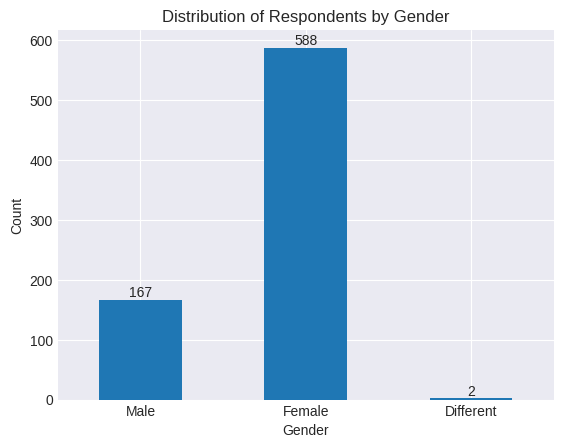

In [ ]:
gender_counts = scommerce_df['Gender'].value_counts().sort_index()

gender_labels = {
    1: 'Male',
    2: 'Female',
    3: 'Different'
}

gender_counts.index = gender_counts.index.map(gender_labels)

ax = gender_counts.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Respondents by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

The results show that **Females** make up the largest proportion of the sample, with **588 respondents**, followed by **Males** with **167 respondents**. The **Different** group represents the smallest proportion of respondents, with **2 respondents**. This distribution provides an overview of the demographic composition of the study participants and may be considered when interpreting subsequent analyses.

### Income Distribution

Monthly income categories were analyzed to understand the economic background of the respondents.

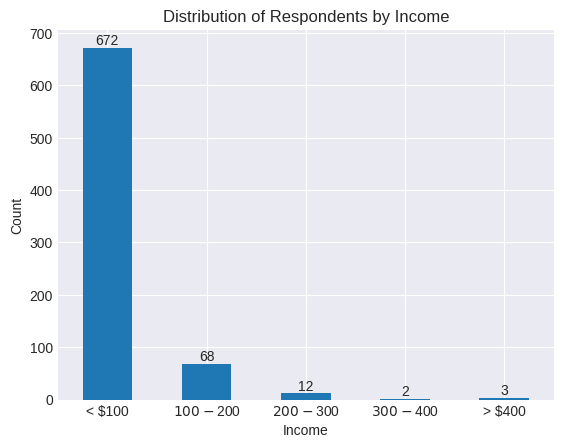

In [ ]:
income_counts = scommerce_df['Income'].value_counts().sort_index()

income_labels = {
    1: '< $100',
    2: '$100 - $200',
    3: '$200 - $300',
    4: '$300 - $400',
    5: '> $400'
}

income_counts.index = income_counts.index.map(income_labels)

ax = income_counts.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Respondents by Income')
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

The bar chart shows that the majority of respondents belong to the **< \$100** income category, comprising **672 respondents**. This is followed by the **\$100-\$200** income group with **68 respondents** and the **\$200-\$300** income group with **12 respondents**. Only a small number of respondents fall within the higher income categories, with **2 respondents** in the **\$300-\$400** range and **3 respondents** earning **more than \$400**. Overall, the sample is heavily concentrated in the lowest income bracket, indicating that most respondents have relatively low income levels. This distribution is expected since the study's participants are university students who may have either limited personal income or rely on financial support from their families.

#### Residential Area Distribution

The residential location of respondents was examined to determine whether the sample is concentrated in urban, suburban, or rural areas.

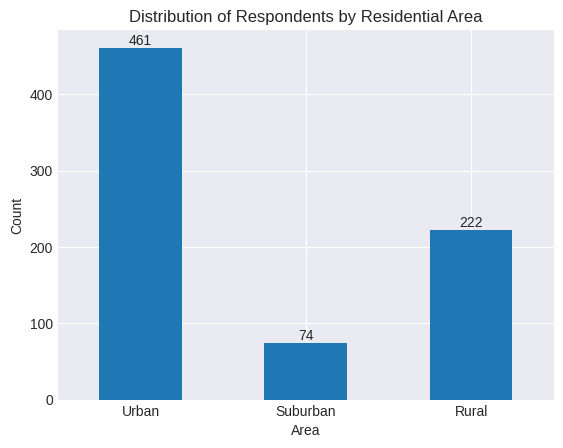

In [ ]:
area_counts = scommerce_df['Area'].value_counts().sort_index()

area_labels = {
    1: 'Urban',
    2: 'Suburban',
    3: 'Rural'
}

area_counts.index = area_counts.index.map(area_labels)

ax = area_counts.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Respondents by Residential Area')
plt.xlabel('Area')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

The bar chart shows that the majority of respondents reside in **urban areas**, accounting for **461 respondents**. This is followed by **rural areas**, with **222 respondents**, while **suburban areas** represent the smallest group, with **74 respondents**. This distribution suggests that the study captures perspectives from respondents across different residential settings, which may influence their access to technology, online platforms, and social commerce activities.

#### Frequency of Social Media Usage

Since the study focuses on social commerce, the frequency of social media use provides important context regarding respondents' exposure to social commerce platforms.

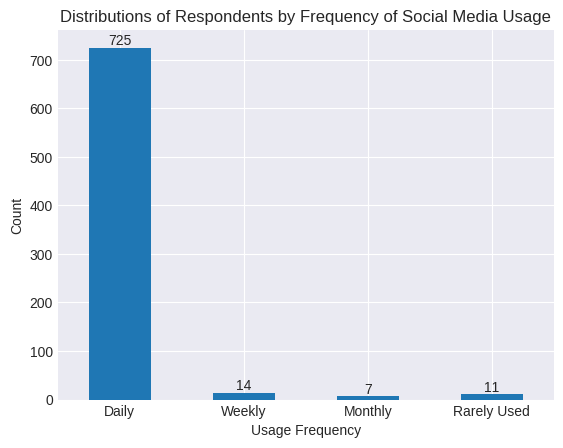

In [ ]:
freq_counts = scommerce_df['Frequently'].value_counts().sort_index()

frequency_labels = {
    1: 'Daily',
    2: 'Weekly',
    3: 'Monthly',
    4: 'Rarely Used'
}

freq_counts.index = freq_counts.index.map(frequency_labels)

ax = freq_counts.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distributions of Respondents by Frequency of Social Media Usage')
plt.xlabel('Usage Frequency')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

The bar chart reveals that the majority of the respondents use social media **daily**, accounting for **725 respondents**. In contrast, only **14 respondents** reported using social media **weekly**, **7 respondents** reported **monthly** usage, and **11 respondents** indicated that they **rarely** use social media. The results indicate that the sample is highly engaged with social media, making it appropriate for investigating social commerce-related behaviors and perceptions.

#### Summary

The demographic profile of the respondents indicates that the sample primarily consists of university students with characteristics that align with the target population of the study. In terms of gender, the sample is composed of respondents from different gender categories, with Females representing the largest proportion. Regarding income, the majority of respondents reported earning less than $100, reflecting the limited financial resources typically associated with university students who may rely on parental support, allowances, or part-time employment. With respect to residential area, most respondents reside in urban areas, although a substantial number come from rural communities, providing representation from diverse living environments. Finally, social media usage is highly prevalent among the respondents, with the vast majority reporting daily use of social media platforms. Collectively, these demographic characteristics suggest that the sample is composed of digitally active university students who are well-positioned to provide insights into social commerce behaviors and perceptions.

#### **2. How are each of the constructs (PU, PEU, FSC, SP, TP, IB, AUB) distributed among respondents?**

To understand how each construct is distributed among respondents, descriptive statistics and histograms are generated for the composite scores. The descriptive statistics provide information about the central tendency and spread of the data, while the histograms help visualize the shape of each distribution. This analysis allows us to identify whether respondents generally reported high or low levels of each construct and whether the scores are approximately normally distributed.

In [ ]:
# Summary statistics for the composite constructs
constructs = ['PU', 'PEU', 'FSC', 'SP', 'TP', 'IB', 'AUB']

# Generate descriptive statistics
scommerce_df[constructs].describe()

,PU,PEU,FSC,SP,TP,IB,AUB
count,757.000000,757.000000,757.000000,757.000000,757.000000,757.000000,757.000000
mean,3.773448,3.700132,3.730956,3.601717,3.557023,3.606011,3.676684
std,0.702081,0.710670,0.749862,0.701395,0.730930,0.703760,0.707042
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.250000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,4.000000,4.000000,4.000000,3.750000,3.666667,3.750000,3.750000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Across all constructs, the mean scores ranged from 3.56 to 3.77, indicating that respondents generally reported moderate to high levels of the measured constructs.

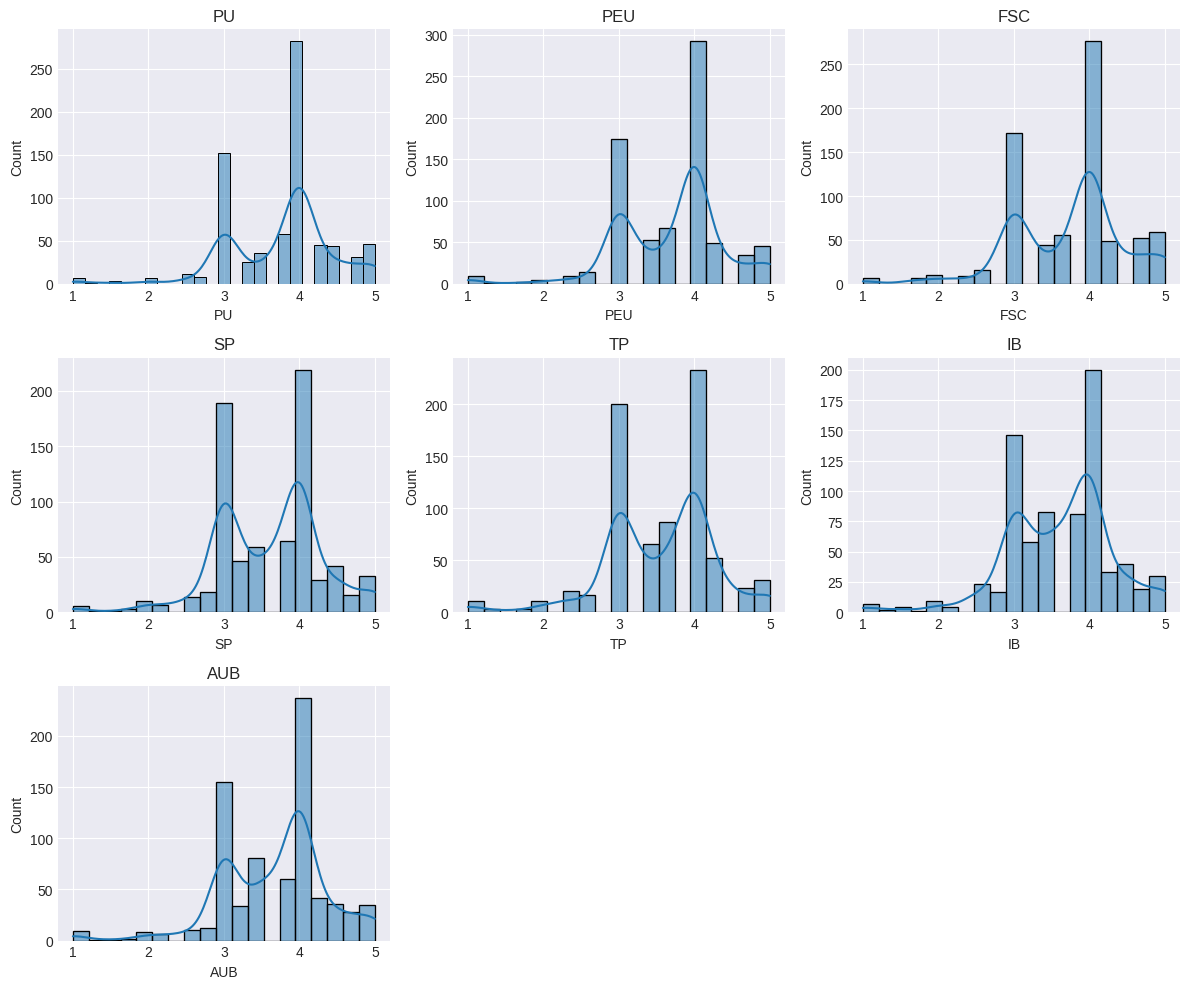

In [ ]:
# Plot distributions of the composite constructs
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, construct in enumerate(constructs):
    sns.histplot(
        scommerce_df[construct],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(construct)

# Remove unused subplots
for j in range(len(constructs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The histograms of all composite constructs show similarities in terms of their distributional patterns, where responses are concentrated around scores of 3 and 4. In particular, the distributions show a secondary peak near 3 and a more prominent peak near 4, indicating that respondents generally reported moderate to high levels across all constructs. This pattern suggests that while some respondents provided neutral evaluations, a larger proportion tended to agree with the survey statements, resulting in higher composite scores. Overall, the distributions are not perfectly normal and show characteristics of a bimodal distribution, although the exact frequencies are different across constructs.

#### **3. How are the behavioral/perception constructs (PU, PEU, FSC, SP, TP, IB) related to each other?**

The dataset measures several behavioral and perception constructs associated with social commerce adoption. These constructs include Perceived Usefulness (`PU`), Perceived Ease of Use (`PEU`), Familiarity with Social Commerce (`FSC`), Social Presence (`SP`), Trust in Platform (`TP`), Interaction Behavior (`IB`), Actual Usage Behavior (`AUB`).

Understanding how these constructs relate to one another can provide insights into whether positive perceptions of social commerce platforms are associated with greater trust, familiarity, and user engagement. To investigate these relationships, composite scores were calculated by averaging the survey items belonging to each construct. Pearson correlation analysis was then performed on the resulting construct scores.

Construct Score Computation

The following code computes the average score for each construct:

In [ ]:
scommerce_df['PU'] = scommerce_df[['PU1','PU2','PU3','PU4']].mean(axis=1)
scommerce_df['PEU'] = scommerce_df[['PEU1','PEU2','PEU3']].mean(axis=1)
scommerce_df['FSC'] = scommerce_df[['FSC1','FSC2','FSC3']].mean(axis=1)
scommerce_df['SP'] = scommerce_df[['SP1','SP2','SP3','SP4']].mean(axis=1)
scommerce_df['TP'] = scommerce_df[['TP1','TP2','TP3']].mean(axis=1)
scommerce_df['IB'] = scommerce_df[['IB1','IB2','IB3','IB4']].mean(axis=1)
scommerce_df['AUB'] = scommerce_df[['AUB1','AUB2','AUB3','AUB4']].mean(axis=1)

Correlation Matrix

Pearson correlation coefficients were computed to measure the strength and direction of the relationships between the constructs.

The resulting table shows the correlation coefficient between every pair of constructs.

In [ ]:
constructs = scommerce_df[['PU','PEU','FSC','SP','TP','IB', 'AUB']]

corr_matrix = constructs.corr(method='pearson')

print(corr_matrix)

           PU       PEU       FSC        SP        TP        IB       AUB
PU   1.000000  0.788226  0.804070  0.718057  0.676910  0.655539  0.771895
PEU  0.788226  1.000000  0.776458  0.717394  0.674808  0.691334  0.785858
FSC  0.804070  0.776458  1.000000  0.766774  0.710337  0.657147  0.744687
SP   0.718057  0.717394  0.766774  1.000000  0.734756  0.644206  0.691883
TP   0.676910  0.674808  0.710337  0.734756  1.000000  0.663131  0.662269
IB   0.655539  0.691334  0.657147  0.644206  0.663131  1.000000  0.683213
AUB  0.771895  0.785858  0.744687  0.691883  0.662269  0.683213  1.000000


Correlation Heatmap

To visualize these relationships more clearly, a heatmap was generated.

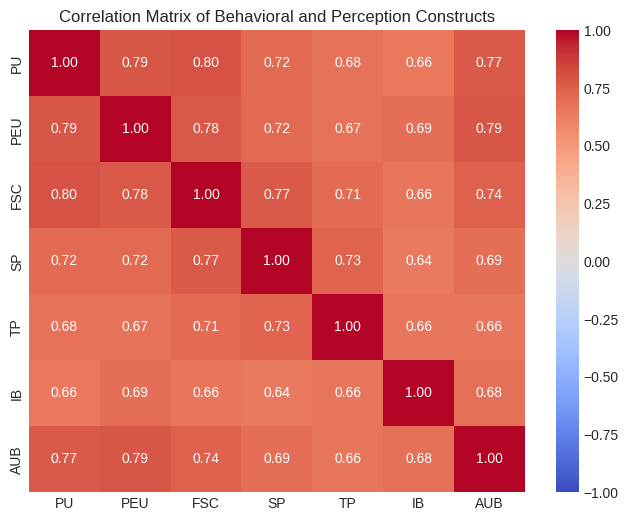

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
	corr_matrix,
	annot=True,
	cmap='coolwarm',
	vmin=-1,
	vmax=1,
	fmt='.2f'
)

plt.title('Correlation Matrix of Behavioral and Perception Constructs')
plt.show()

#### Interpretation

The correlation matrix reveals that all behavioral and perception constructs exhibit **positive correlations**, with coefficients ranging from **0.63 to 0.80**. This indicates that respondents who score highly on one construct generally tend to score highly on the others as well.

The **strongest relationship** was observed between **Perceived Usefulness (PU)** and **Familiarity with Social Commerce (FSC)** (*r* = 0.80). This suggests that respondents who are more familiar with social commerce platforms are also more likely to perceive them as useful. A similarly strong relationship was found between **Perceived Usefulness (PU)** and **Perceived Ease of Use (PEU)** (*r* = 0.79), indicating that platforms that are easier to use are often perceived as more useful.

Other notable positive relationships include:

* **PEU and FSC** (*r* = 0.78)
* **FSC and Social Presence (SP)** (*r* = 0.76)
* **SP and Trust in Platform (TP)** (*r* = 0.72)
* **FSC and TP** (*r* = 0.71)

These findings suggest that familiarity, ease of use, usefulness, social interaction, and trust are closely interconnected aspects of social commerce behavior.

The **weakest relationship** was observed between **Social Presence (SP)** and **Interaction Behavior (IB)** (*r* = 0.63). Although this is the lowest correlation in the matrix, it still represents a moderate positive relationship, indicating that users who experience greater social presence are somewhat more likely to engage in interaction behaviors.

Overall, the results suggest that the constructs do not operate independently. Instead, positive perceptions of social commerce platforms tend to occur together with higher levels of trust, familiarity, social presence, and interaction behavior. This supports the idea that improving one aspect of the user experience may positively influence other aspects of social commerce engagement.

#### **4. Which of these constructs show the strongest relationship with AUB specifically?**

As the potential target variable, it is also important to examine how each behavioral and perception construct relates to Actual Usage Behavior (AUB). The correlation matrix was therefore extended to include AUB, allowing the strength of its relationship with each construct to be compared.

The correlation analysis indicates that all behavioral and perception constructs exhibit positive relationships with **Actual Usage Behavior (AUB)**, with correlation coefficients ranging from **0.66 to 0.79**. Among the constructs, **Perceived Ease of Use (PEU)** demonstrated the strongest positive correlation with AUB **(r = 0.79)**, followed by **Perceived Usefulness (PU) (r = 0.77)** and **Familiarity with Social Commerce (FSC) (r = 0.74)**. These findings suggest that respondents who perceive social commerce platforms as easier to use, more useful, and are more familiar with them tend to report higher levels of actual usage.

In contrast, **Trust in Platform (TP)** exhibited the weakest positive correlation with AUB **(r = 0.66)**, although the relationship remains moderately positive. Overall, the results indicate that all six constructs are positively associated with Actual Usage Behavior, supporting their inclusion as potential predictor variables in the subsequent machine learning models.

#### **5. How does Actual Usage Behavior vary across demographic groups?**

This analysis examines the distribution of Actual Usage Behavior (AUB) across different demographic categories, including gender, income level, residential area, and social media usage frequency. Descriptive statistics and visualizations are used to identify potential patterns and differences among groups.


#### A. AUB Across Genders

The distribution of Actual Usage Behavior (AUB) across gender categories is examined using descriptive statistics and boxplots. As only two respondents belonged to the "Different" gender category, this group was excluded from further analysis due to insufficient sample size. Consequently, the analysis focuses on male and female respondents.

In [ ]:
gender_df = scommerce_df[scommerce_df['Gender'] != 3]

gender_summary = (
    gender_df
    .groupby('Gender')['AUB']
    .agg(['count', 'mean', 'median', 'std'])
)

gender_summary.index = gender_summary.index.map({
    1: 'Male',
    2: 'Female'
})

gender_summary

,count,mean,median,std
Gender,,,,
Male,167,3.658683,3.75,0.789311
Female,588,3.686650,4.00,0.674685


To better visualize the distribution of Actual Usage Behavior (AUB) across gender groups, a box plot is presented below.

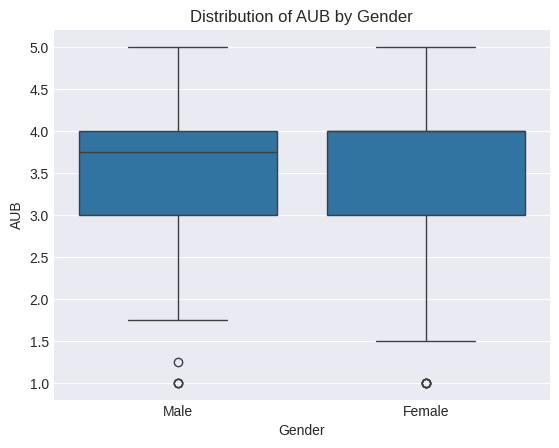

In [ ]:
sns.boxplot(
    data=gender_df,
    x='Gender',
    y='AUB'
)

plt.xticks([0, 1], ['Male', 'Female'])

plt.title('Distribution of AUB by Gender')
plt.xlabel('Gender')
plt.ylabel('AUB')

plt.show()

Both the table and figure above present the distribution of Actual Usage Behavior (AUB) across male and female respondents. Female respondents showed a slightly higher mean AUB score (M = 3.69, SD = 0.67) than male respondents (M = 3.66, SD = 0.79), while the median AUB score was also higher among females (Median = 4.00) compared to males (Median = 3.75). Nevertheless, the difference between the two groups appears minimal. The boxplot further supports this observation, as both genders exhibit highly similar distributions and central tendencies.

While the descriptive statistics and boxplot suggest only minor differences in Actual Usage Behavior (AUB) between male and female respondents, it is not sufficient to infer significant difference. Therefore, an independent samples t-test was conducted to assess whether the mean AUB scores differ significantly between the two gender groups.

For this, the null hypothesis states that there is no significant difference in the mean AUB scores of male and female respondents. A significance level of α = 0.05 is adopted for all inferential statistical tests conducted in this study.

- $H_0: \mu_{Male} = \mu_{Female}$
- $H_1: \mu_{Male} \ne \mu_{Female}$

In [ ]:
male = gender_df[gender_df['Gender'] == 1]['AUB']
female = gender_df[gender_df['Gender'] == 2]['AUB']

t_stat, p_value = stats.ttest_ind(
    male,
    female,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: -0.4167
P-value: 0.6773


An independent samples t-test was conducted to determine whether Actual Usage Behavior (AUB) differed significantly between male and female respondents. The results indicated no statistically significant difference in mean AUB scores between the two groups, t = -0.417, p = 0.677. Since the p-value exceeds the significance level of 0.05, the null hypothesis cannot be rejected. The findings suggest that AUB does not differ significantly between male and female respondents.

#### 2. AUB Across Income

This section explores how Actual Usage Behavior (AUB) varies across income groups. Descriptive statistics and visualizations are used to identify any noticeable differences in AUB among respondents with different income levels. Before proceeding, the distribution of respondents across income categories is examined, as substantial differences in group sizes may affect the interpretation of the results.



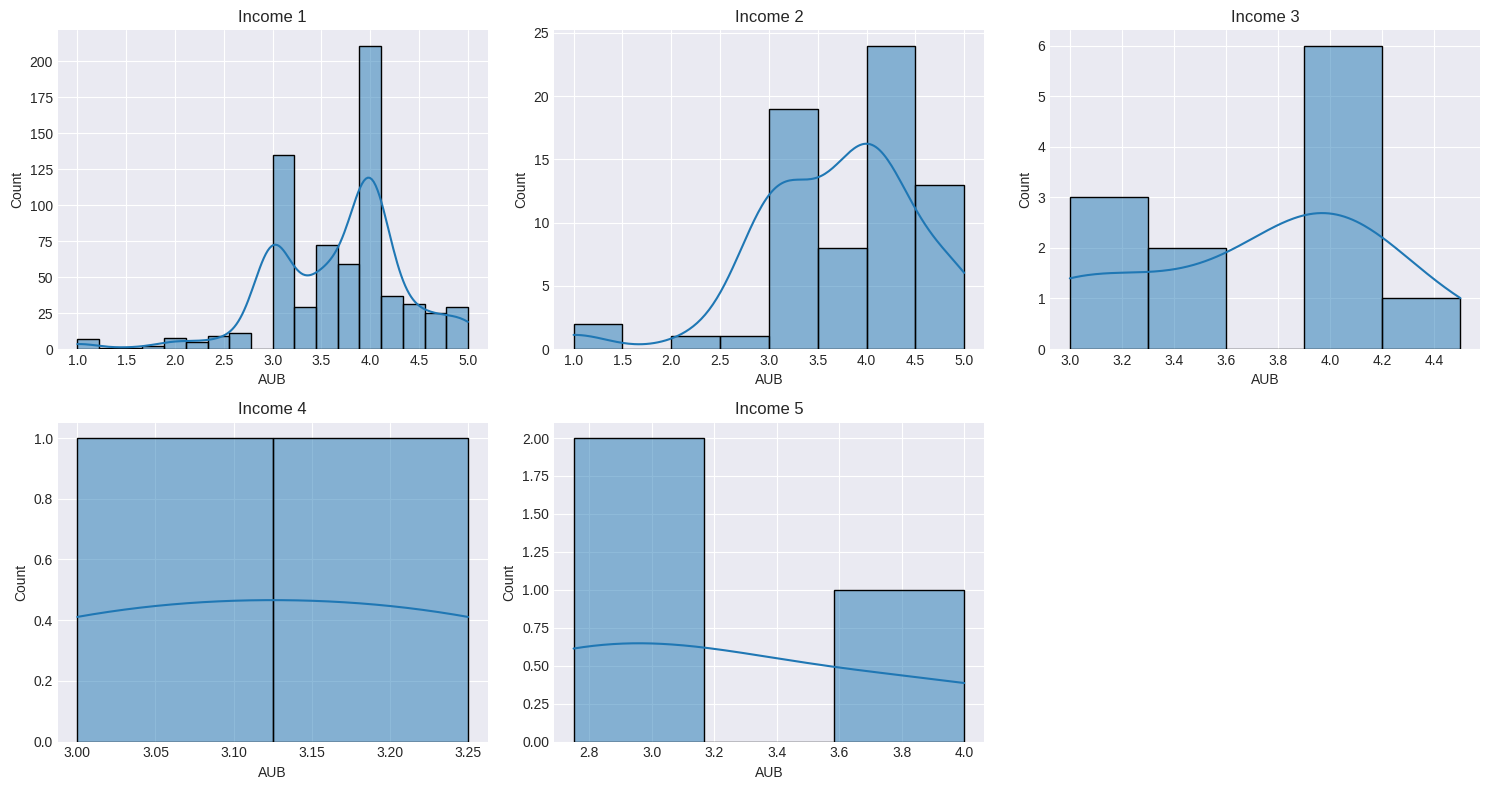

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()

for i, income in enumerate(sorted(scommerce_df['Income'].unique())):
    sns.histplot(
        scommerce_df[scommerce_df['Income'] == income]['AUB'],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f'Income {income}')
    axes[i].set_xlabel('AUB')
    axes[i].set_ylabel('Count')

# Remove unused subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

The income groups are highly imbalanced, with most respondents belonging to the lowest income category. Additionally, the highest income groups contain very few respondents. The histograms also show that the distributions do not closely resemble a normal distribution, particularly for the smallest groups. As a result, formal inferential tests such as one-way ANOVA were not performed, and the analysis focuses on descriptive comparisons instead.

#### 3. AUB Across Area

This section explores how Actual Usage Behavior (AUB) varies across different areas of residence. Descriptive statistics and visualizations are used to identify potential differences in AUB among respondents living in urban, suburban, and rural areas.

In [ ]:
area_summary = (
    scommerce_df
    .groupby('Area')['AUB']
    .agg(['count', 'mean', 'median', 'std'])
)

area_summary.index = area_summary.index.map({
    1: 'Urban',
    2: 'Suburban',
    3: 'Rural'
})

area_summary

,count,mean,median,std
Area,,,,
Urban,461,3.711497,4.00,0.700356
Suburban,74,3.641892,3.75,0.691288
Rural,222,3.615991,3.75,0.724337


The above presents the descriptive statistics of AUB across areas of residence. To better visualize the distribution of AUB among respondents from urban, suburban, and rural areas, a boxplot is presented below.

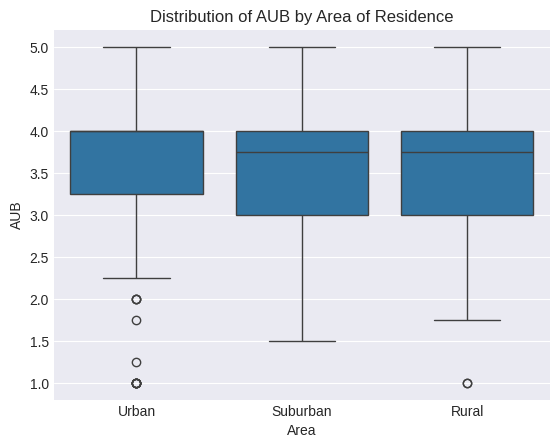

In [ ]:
sns.boxplot(
    data=scommerce_df,
    x='Area',
    y='AUB'
)

plt.xticks(
    [0, 1, 2],
    ['Urban', 'Suburban', 'Rural']
)

plt.title('Distribution of AUB by Area of Residence')
plt.xlabel('Area')
plt.ylabel('AUB')

plt.show()

The table and figure present the distribution of AUB across areas of residence. Respondents residing in urban areas exhibited the highest mean AUB score (M = 3.71, SD = 0.70), followed by those residing in suburban areas (M = 3.64, SD = 0.69) and rural areas (M = 3.62, SD = 0.72). The median AUB score was 4.00 for urban respondents and 3.75 for both suburban and rural respondents.

While the descriptive statistics and boxplot suggest only minor differences in Actual Usage Behavior (AUB) across areas of residence, visual inspection alone is insufficient to determine whether these differences are statistically significant. Therefore, a one-way ANOVA was conducted to assess whether the mean AUB scores differ significantly among respondents residing in urban, suburban, and rural areas.

For this analysis, the null hypothesis states that there is no significant difference in the mean AUB scores across the three areas of residence. A significance level of α = 0.05 is adopted for all inferential statistical tests conducted in this study.

- $H_0: \mu_{Urban} = \mu_{Suburban} = \mu_{Rural}$
- $H_1:$ At least one group mean differs from the others.

In [ ]:
urban = scommerce_df[scommerce_df['Area'] == 1]['AUB']
suburban = scommerce_df[scommerce_df['Area'] == 2]['AUB']
rural = scommerce_df[scommerce_df['Area'] == 3]['AUB']

f_stat, p_value = stats.f_oneway(
    urban,
    suburban,
    rural
)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 1.4681
P-value: 0.2310


A One-Way ANOVA was conducted to determine whether significant differences exist among the Urban, Suburban, and Rural groups. The analysis produced an F-statistic of 1.4681 and a p-value of 0.2310. Since the p-value exceeds the 0.05 significance level, the null hypothesis is not rejected. Thus, there is no statistically significant difference among the mean values of the three groups.

#### 4. AUB Across Frequency

This section explores how AUB varies across respondents with different frequencies of social media usage. Descriptive statistics and visualizations are used to examine potential patterns in AUB among the frequency groups.

In [ ]:
frequency_summary = (
    scommerce_df
    .groupby('Frequently')['AUB']
    .agg(['count', 'mean', 'median', 'std'])
)

frequency_summary.index = frequency_summary.index.map({
    1: 'Daily',
    2: 'Weekly',
    3: 'Monthly',
    4: 'Rarely'
})

frequency_summary

,count,mean,median,std
Frequently,,,,
Daily,725,3.681724,4.00,0.701587
Weekly,14,3.678571,4.00,0.895655
Monthly,7,3.750000,3.75,0.677003
Rarely,11,3.295455,3.25,0.820200


To better understand the distribution, a graph showing the distribution is shown below.

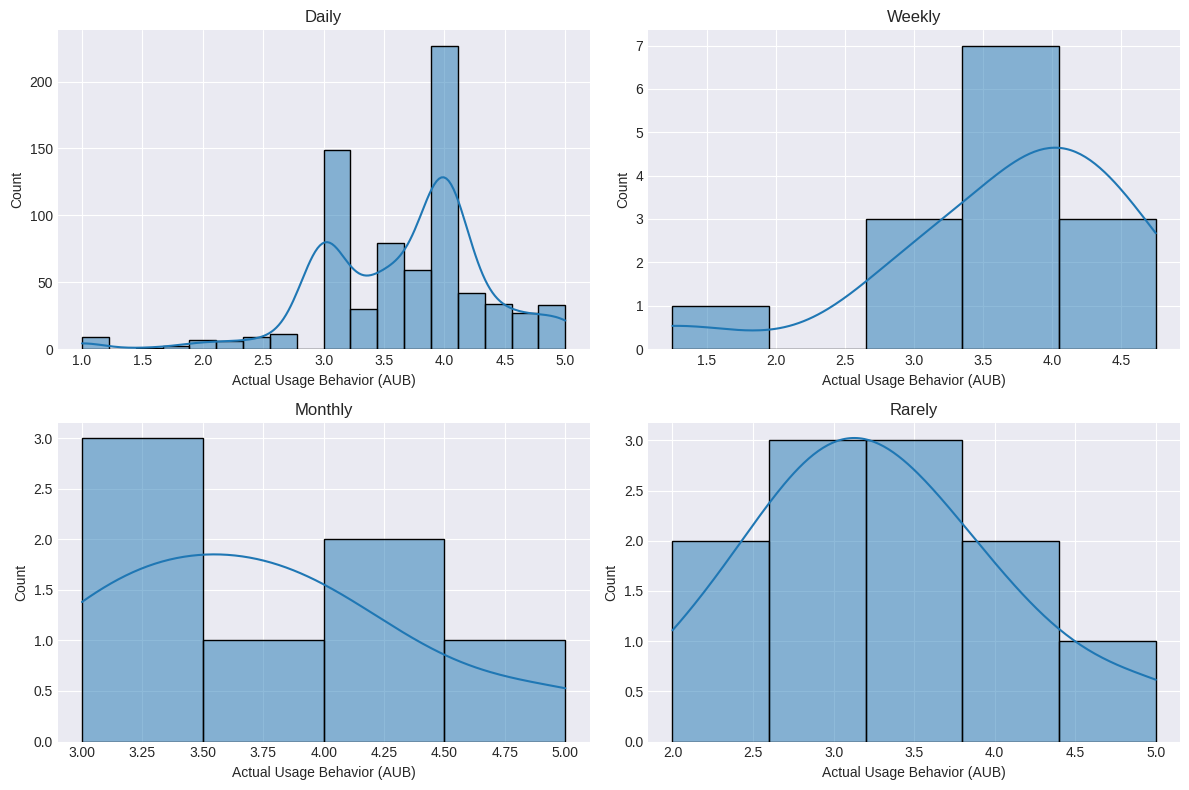

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Label mapping
frequency_labels = {
    1: 'Daily',
    2: 'Weekly',
    3: 'Monthly',
    4: 'Rarely'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, freq in enumerate(sorted(scommerce_df['Frequently'].unique())):
    sns.histplot(
        scommerce_df[scommerce_df['Frequently'] == freq]['AUB'],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(frequency_labels[freq])
    axes[i].set_xlabel('Actual Usage Behavior (AUB)')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

The frequency groups are highly imbalanced, with most respondents reporting daily social media usage. In addition, the weekly, monthly, and rarely used categories contain relatively few observations. Based on the distributions shown above, it is difficult to meaningfully assess the normality assumption for these smaller groups. Therefore, the analysis focuses on descriptive comparisons of AUB across frequency groups rather than formal inferential testing.

### [4] Research Question

#### **How does actual usage behavior differ among clusters of Generation Z university students formed based on their perceived usefulness, perceived ease of use, familiarity with social commerce, social presence, trust in platform, and interaction behavior?**

The exploratory data analysis revealed that the perception and behavioral constructs, Perceived Usefulness (PU), Perceived Ease of Use (PEU), Familiarity with Social Commerce (FSC), Social Presence (SP), Trust in Platform (TP), and Interaction Behavior (IB), are all moderately to strongly positively correlated. This suggests that these constructs are interconnected and may naturally characterize different types of social commerce users.

Building on this finding, the proposed research question seeks to determine whether respondents can be grouped into distinct user segments based on these constructs and whether these segments exhibit different levels of Actual Usage Behavior (AUB). Understanding these differences is important because actual usage behavior reflects the extent to which users actively engage with social commerce platforms, making it a meaningful indicator of platform adoption.

The findings can help businesses and platform developers identify the characteristics of user segments that demonstrate high or low levels of actual usage. Such insights can support the development of targeted marketing strategies, personalized user experiences, and platform improvements aimed at increasing user engagement. From a research perspective, the study also provides a data-driven understanding of how perception- and behavior-based user profiles are associated with actual social commerce usage among Generation Z university students.

## **CBADVAI Phase 2: Machine Learning**

Following the completion of data preparation and exploratory data analysis, machine learning models were developed to predict Actual Usage Behavior (AUB). This section describes the procedures for data splitting, preprocessing, model training, hyperparameter tuning, and performance evaluation.

### [5] Feature and Target Variable Selection

This section describes the predictor and target variables used for machine learning model development. The selected variables were based on the conceptual framework of the original study, with the implementation adapted for a machine learning-based prediction task.

In [ ]:
feature_columns = [
    "PU",
    "PEU",
    "FSC",
    "SP",
    "TP",
    "IB"
]

target_column = "AUB"

X = scommerce_df[feature_columns]
y = scommerce_df[target_column]

The predictor variables consisted of Perceived Usefulness (PU), Perceived Ease of Use (PEU), Familiarity with Social Commerce (FSC), Social Participation (SP), Trust in Platform (TP), and Intention to Buy (IB). These constructs were selected as input features since they were identified in the original study as factors influencing Actual Usage Behavior (AUB) within the proposed conceptual framework.

Actual Usage Behavior (AUB) was designated as the target variable because it represents the primary behavioral outcome of interest in the original study. Rather than testing causal relationships through PLS-SEM, this study reformulated the problem as a supervised machine learning task, where the objective was to predict AUB based on the six behavioral and technological constructs.

### [6] Dataset Partitioning

This section describes how the dataset is partitioned into training and testing subsets to support model development and evaluation. It also defines the cross-validation strategy used during hyperparameter optimization.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Predictor variables
    y,                  # Target variable
    test_size=0.20,     # Reserve 20% of the data for testing
    random_state=1      # Fixed random seed for reproducibility
)

An 80:20 train-test split is adopted, where 80% of the dataset is allocated for model training while the remaining 20% is reserved for final model evaluation. This proportion provides a balance between allowing the models to learn from a sufficient amount of data while preserving an independent test set for assessing generalization performance on unseen observations (TpointTech, 2026).

Because the dataset consists of only 757 observations, a separate validation set is not created. Instead, hyperparameter tuning and model selection are performed using cross-validation on the training data. This approach allows more efficient utilization of the available observations while maintaining an untouched test set for unbiased model evaluation (Prathik, 2025).

The parameter random_state=1 fixes the random seed used during data partitioning, ensuring that the same training and testing subsets are generated whenever the experiment is repeated. This improves the reproducibility of the machine learning pipeline.

#### *Cross Validation*

To support model selection and hyperparameter optimization, a ten-fold cross-validation strategy is defined using the KFold class.

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=10,      # Number of folds (10-fold cross-validation)
    shuffle=True,     # Randomly shuffle the data before splitting
    random_state=1    # Ensures the same shuffled splits are generated every run
)

The KFold object specifies that the training dataset will be partitioned into ten approximately equal folds. During model training, one fold is used as the validation subset while the remaining nine folds are used for training. This process is repeated ten times so that every fold serves as the validation set exactly once, after which the validation results are averaged to estimate the model's performance.

Unlike the conventional train-validation-test approach, this study employs 10-fold cross-validation on the training data instead of creating a separate validation set. Because the dataset contains 757 observations, this approach allows more efficient utilization of the available training data while preserving an independent test set for the final evaluation. Additionally, every training observation contributes to both model training and validation across different iterations, resulting in a more reliable estimate of model performance than relying on a single train-validation split (Prathik, 2025).

A value of n_splits=10 is selected because 10-fold cross-validation is widely regarded as a standard practice in machine learning, providing a favorable balance between reliable performance estimation and computational efficiency (Brownlee, 2020). Furthermore, the parameter shuffle=True randomly shuffles the training observations before partitioning them into folds, reducing potential bias caused by the original ordering of the dataset.

### [7] Feature Scaling
Feature scaling is performed to transform the predictor variables into a common scale prior to model training. This preprocessing step helps reduce differences in feature magnitudes, allowing machine learning algorithms to learn from the data more effectively.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # Initialize the standardization object

X_train_scaled = scaler.fit_transform(
    X_train                # Compute mean and standard deviation from the training set, then standardize it
)

X_test_scaled = scaler.transform(
    X_test                 # Standardize the test set using the training set statistics
)

Standardization is performed using the StandardScaler class from the scikit-learn library. This technique transforms each feature to have a mean of 0 and a standard deviation of 1, reducing the influence of differences in feature magnitudes while preserving the overall distribution of the data.

Standardization is selected instead of normalization because the MLP is trained using gradient-based optimization algorithms, which generally perform better when input features are centered around zero and have comparable variances. In contrast, Min-Max normalization rescales values to a fixed range, typically between 0 and 1, based on the minimum and maximum values of each feature. Because normalization depends directly on these extreme values, it is generally more sensitive to outliers than standardization. Consequently, standardization is preferred for gradient-based learning algorithms, whereas normalization is more commonly applied to distance-based algorithms such as k-Nearest Neighbors (k-NN).

To prevent data leakage, the scaler is fitted only on the training data using fit_transform(). The learned scaling parameters are subsequently applied to the testing data through transform() without recomputing the feature statistics. This ensures that information from the testing set is not introduced during model training, preserving the validity of the model evaluation.

### **[8] Random Forest**

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to produce a more accurate and robust prediction. Instead of relying on a single tree, Random Forest aggregates the predictions of many trees, reducing overfitting while improving generalization.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

The Random Forest hyperparameter search was informed by Probst, Wright, and Boulesteix (2019) and the scikit-learn implementation of Random Forest Regression. The selected hyperparameters were chosen to balance established recommendations with the characteristics of the present dataset, which consists of 757 observations and six predictor variables.

* The `n_estimators` values of 100, 200, and 300 were selected to examine whether increasing the number of trees improves model stability and predictive performance. The value of 100 provides a standard baseline, while higher values allow the effect of additional trees to be evaluated, consistent with Probst et al. (2019), who note that increasing the number of trees generally improves stability but provides diminishing returns as the forest becomes larger.

* The `max_features` values of 2, 3, and 6 were included because Probst et al. identify the number of candidate predictors at each split (`mtry`) as an important Random Forest hyperparameter. With six predictors, a value of 2 corresponds to the commonly discussed ($\frac{p}{3}$) setting for regression, while 3 approximates ($\sqrt{p}$), and 6 allows all predictors to be considered at each split.

* The `max_depth` values of None, 10, and 20 were selected to evaluate different levels of tree complexity, ranging from unrestricted growth to progressively constrained trees.

* The `min_samples_split` values of 2 and 5 were included to compare the standard minimum split requirement with a more restrictive setting, while `min_samples_leaf` values of 1, 2, and 5 were selected to evaluate different levels of node-size restriction. The value of 5 is particularly relevant because Probst et al. (2019) discuss a node size of approximately 5 as a typical setting for Random Forest regression.

Overall, these hyperparameters provide a literature-informed search space that allows the model to evaluate different levels of ensemble size, feature randomization, and tree complexity. Grid search with cross-validation was then used to determine which configuration provided the best predictive performance for the present dataset, rather than assuming that any single configuration was universally optimal.

In [ ]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_features": [2, 3, 6],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 5]
}

"""
Default values in scikit-learn:
  RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
  )
"""

'\nDefault values in scikit-learn:\n  RandomForestRegressor(\n    n_estimators=100,\n    max_depth=None,\n    min_samples_split=2,\n    min_samples_leaf=1,\n  )\n'

| Hyperparameter       | Description                                                                          |
| -------------------- | ------------------------------------------------------------------------------------ |
| `n_estimators`        | Determines the number of decision trees in the Random Forest.                       |
| `max_features`        | Specifies the number of features considered when determining the best split.        |
| `max_depth`           | Controls the maximum depth of each decision tree.                                   |
| `min_samples_split`   | Specifies the minimum number of samples required to split an internal node.         |
| `min_samples_leaf`    | Specifies the minimum number of samples required in a leaf node.                    |

The code below initializes the GridSearchCV object for the Random Forest Regressor using the predefined hyperparameter search space. The model is configured with a fixed random seed to ensure reproducible results. Hyperparameter combinations are evaluated using the 10-fold cross-validation strategy, with negative mean squared error (MSE) as the optimization metric. Parallel processing is also enabled to evaluate the search space more efficiently.

In [ ]:
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=1),  # Base Random Forest model
    param_grid=param_grid_rf,                         # Hyperparameter combinations to evaluate
    cv=kf,                                            # 10-fold cross-validation strategy
    scoring="neg_mean_squared_error",                 # Optimize based on negative MSE
    n_jobs=-1                                         # Use all available CPU cores for parallel processing
)

After initializing the GridSearchCV object, the model fitting process can begin. During training, GridSearchCV systematically evaluates every possible combination of the specified Random Forest hyperparameters using the training data and 10-fold cross-validation.

In [ ]:
grid_rf.fit(
    X_train,    # Training predictor variables
    y_train     # Training target variable
)

GridSearchCV(cv=KFold(n_splits=10, random_state=1, shuffle=True),
             estimator=RandomForestRegressor(random_state=1), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20], 'max_features': [2, 3, 6],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error')

The hyperparameter combination that achieved the best average performance during the GridSearchCV search was displayed, along with its corresponding cross-validation Mean Squared Error (MSE). Since GridSearchCV maximizes the negative MSE score, the value was multiplied by **-1** to obtain the actual MSE, where lower values indicate better predictive performance.

In [ ]:
print("===== Best Hyperparameters =====")
print(
    grid_rf.best_params_    # Display the hyperparameter combination with the best cross-validation performance
)

print("\nBest Cross-Validation MSE:")
print(
    -grid_rf.best_score_    # Convert the negative MSE back to a positive Mean Squared Error
)

===== Best Hyperparameters =====
{'max_depth': 10, 'max_features': 2, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

Best Cross-Validation MSE:
0.1626779305484416


The GridSearchCV results were converted into a DataFrame to summarize the performance of each hyperparameter combination. The selected columns display the values of the Random Forest hyperparameters, the mean cross-validation score, and the corresponding ranking.

In [ ]:
results = pd.DataFrame(
    grid_rf.cv_results_
)

results[
    [
        "param_n_estimators",          # Number of trees
        "param_max_features",          # Number of features considered at each split
        "param_max_depth",             # Maximum tree depth
        "param_min_samples_split",     # Minimum samples required to split a node
        "param_min_samples_leaf",      # Minimum samples required at a leaf node
        "mean_test_score",             # Mean cross-validation score (negative MSE)
        "rank_test_score"              # Ranking of each hyperparameter combination
    ]
].sort_values(
    "rank_test_score"
)

,param_n_estimators,param_max_features,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,rank_test_score
65,300,2,10,5,2,-0.162678,1
62,300,2,10,2,2,-0.162730,2
64,200,2,10,5,2,-0.162991,3
61,200,2,10,2,2,-0.163077,4
119,300,2,20,5,2,-0.163318,5
...,...,...,...,...,...,...,...
146,300,6,20,2,1,-0.178953,158
37,200,6,None,2,1,-0.179837,159
145,200,6,20,2,1,-0.179854,160
36,100,6,None,2,1,-0.181904,161


The output shows the selected hyperparameter values, their mean cross-validation score, and their corresponding rank. Since the scoring metric is negative Mean Squared Error (MSE), values closer to zero indicate better predictive performance. The best-performing configuration was **300 trees, 2 features considered at each split, a maximum depth of 10, a minimum of 5 samples required to split a node, and a minimum of 2 samples per leaf**, which achieved a mean cross-validation score of **-0.162678** and was ranked **1st**. The second- and third-ranked configurations produced very similar scores of **-0.162730** and **-0.162991**, respectively, indicating only small differences in cross-validation performance among the top configurations. In contrast, the lowest-ranked configuration had a score of **-0.181909**, showing poorer cross-validation performance. The results are sorted by **rank_test_score** so that the best-performing configurations appear first.

The best-performing Random Forest model identified by GridSearchCV was retrieved and used to generate predictions on the test dataset. The selected model corresponds to the hyperparameter combination that achieved the best average performance during the cross-validation process, while the test data was used to evaluate its predictive performance on unseen observations.

In [ ]:
best_rf = grid_rf.best_estimator_    # Retrieve the best-performing Random Forest model

rf_pred = best_rf.predict(
    X_test                           # Generate predictions for the test data
)

The required evaluation metrics were imported to assess the Random Forest model's predictive performance. Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² score were used to evaluate the differences between the actual and predicted values, while NumPy was imported to support numerical calculations.

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

The tuned Random Forest model was evaluated on the test set using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R². The MAE, MSE, and RMSE values measure the magnitude of prediction errors, with lower values indicating better performance, while the R² score measures the proportion of variance in the target variable explained by the model, with higher values indicating better predictive performance. The resulting metrics provide an overall assessment of the model's predictive performance on unseen test data.

In [ ]:
print("===== Tuned Random Forest =====")

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("\nEvaluation on Test Set")
print(f"MAE : {rf_mae:.4f}")
print(f"MSE : {rf_mse:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²  : {rf_r2:.4f}")

===== Tuned Random Forest =====

Evaluation on Test Set
MAE : 0.2304
MSE : 0.1304
RMSE: 0.3611
R²  : 0.7520


#### **Interpretation of Metrics**

The optimized Random Forest model achieved a **Mean Absolute Error (MAE)** of **0.2304**, indicating that its predictions differed from the actual AUB values by an average of approximately **0.23** on the five-point Likert scale. This relatively low error suggests that the model is generally able to predict respondents' Actual Usage Behavior with good accuracy.

The model also obtained a **Mean Squared Error (MSE)** of **0.1304** and a **Root Mean Squared Error (RMSE)** of **0.3611**. Since RMSE is expressed in the same unit as the target variable, it indicates that the model's predictions typically deviate from the actual AUB values by approximately **0.36 points**. The difference between the MAE and RMSE is relatively small, suggesting that although some larger prediction errors may be present, they do not substantially increase the model's overall error.

Furthermore, the optimized Random Forest achieved an **R² score of 0.7520**, indicating that approximately **75.2%** of the variation in Actual Usage Behavior can be explained by the predictor variables included in the model. This suggests that the behavioral and perception constructs collectively provide strong predictive information for estimating AUB, with the model accounting for a substantial proportion of the observed variation in the target variable.

In conclusion, the evaluation metrics indicate that the tuned Random Forest model produces accurate predictions while maintaining good generalization on unseen data. The relatively low MAE and RMSE, together with the **R² value of 0.7520**, demonstrate that the model effectively captures the relationship between the behavioral constructs and Actual Usage Behavior. Although some prediction error remains, the model explains a substantial proportion of the variation in AUB and demonstrates strong predictive performance on the test set.

The actual and predicted AUB values were visualized using a scatter plot to assess the Random Forest model's prediction performance. The **actual values** are plotted on the x-axis, while the **predicted values** are plotted on the y-axis. The dashed reference line represents perfect predictions, where the predicted value is equal to the actual value. Points located closer to this line indicate more accurate predictions, while greater deviations from the line represent larger prediction errors.

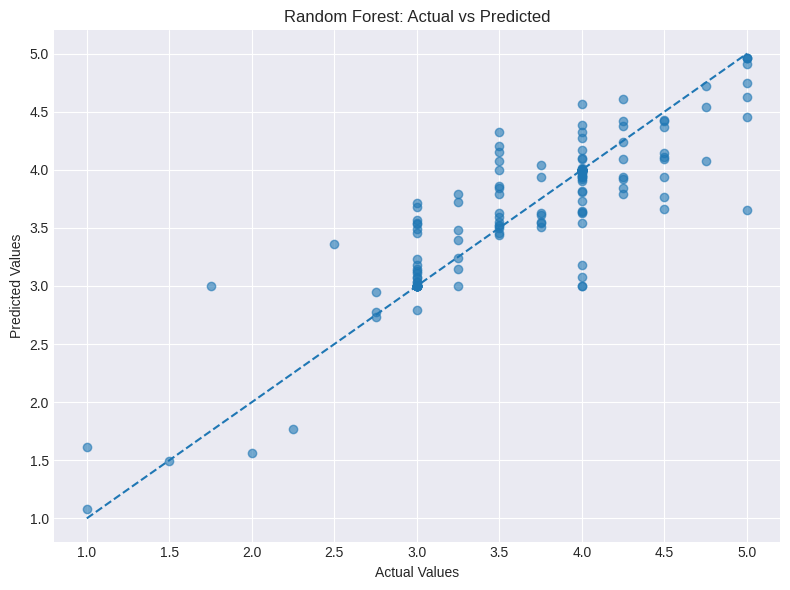

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(
    figsize=(8, 6)          # Set the figure size
)

plt.scatter(
    y_test,                 # Actual target values
    rf_pred,                # Predicted target values
    alpha=0.6               # Set point transparency
)

plt.plot(
    [y_test.min(), y_test.max()],    # Minimum and maximum actual values (x-axis)
    [y_test.min(), y_test.max()],    # Minimum and maximum actual values (y-axis)
    linestyle="--"                   # Reference line representing perfect predictions
)

plt.xlabel("Actual Values")          # Label the x-axis
plt.ylabel("Predicted Values")       # Label the y-axis
plt.title("Random Forest: Actual vs Predicted")  # Set the plot title

plt.tight_layout()                   # Adjust spacing to prevent overlapping elements
plt.show()                           # Display the plot

#### **Interpretation of Scatter Plot**

The scatter plot compares the **actual AUB values** with the **predicted AUB values** generated by the optimized Random Forest model. The dashed diagonal line represents perfect predictions, where the predicted value is equal to the actual value. Overall, the points show a clear positive relationship and are generally concentrated around the reference line, indicating that the model is able to capture the overall pattern of Actual Usage Behavior.

The predictions are particularly well aligned with the actual values at the lower and upper ends of the scale. For example, observations with actual values close to **1.0 and 5.0** generally have predictions that are relatively close to their corresponding actual values. This suggests that the model is able to distinguish respondents with relatively low and high AUB values reasonably well.

However, greater dispersion can be observed around the middle-to-upper portion of the scale, particularly for actual values between approximately **3.0 and 4.5**. Several observations fall noticeably above or below the reference line, indicating that the model produces larger prediction errors for some observations in this range. The clustering of points around actual values of **3.0, 3.5, and 4.0** also suggests that predictions are concentrated around these common response levels.

Overall, the scatter plot indicates **reasonably strong agreement between the actual and predicted values**, as reflected by the general concentration of observations around the diagonal reference line. This visual pattern is consistent with the model's **R² of 0.7520**, which indicates that the Random Forest explains approximately **75.2% of the variation in AUB** on the test set. Nevertheless, the dispersion of some points away from the reference line demonstrates that the model does not perfectly predict every observation, which is also reflected in the **MAE of 0.2304** and **RMSE of 0.3611**.

To further assess the prediction performance of the optimized Random Forest model, the residuals were calculated as the difference between the actual and predicted AUB values and plotted against the predicted values. The dashed horizontal line at **zero** represents perfect predictions, where the actual and predicted values are equal. Residuals close to zero indicate smaller prediction errors, while larger positive or negative residuals indicate greater underprediction or overprediction, respectively.

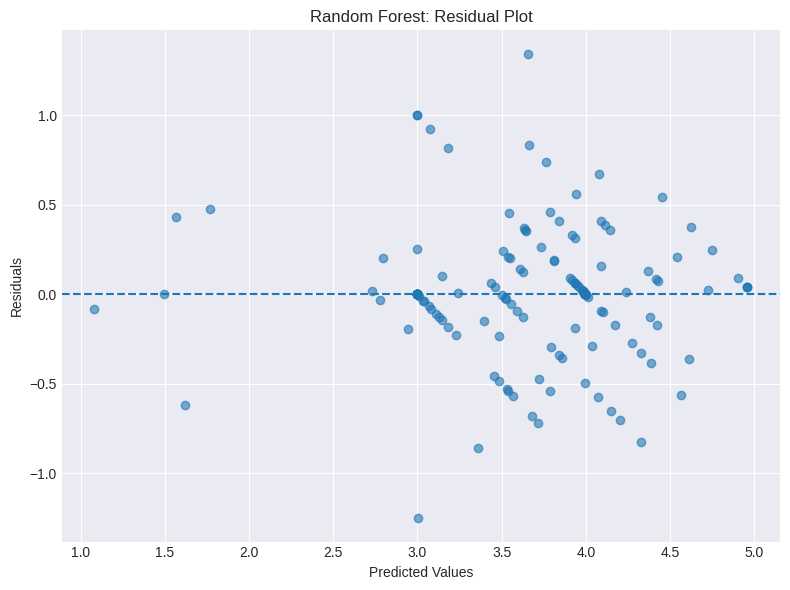

In [ ]:
rf_residuals = y_test - rf_pred    # Compute the residuals (actual - predicted)

plt.figure(
    figsize=(8, 6)                 # Set the figure size
)

plt.scatter(
    rf_pred,                       # Predicted target values
    rf_residuals,                  # Residual values
    alpha=0.6                      # Set point transparency
)

plt.axhline(
    y=0,                           # Reference line indicating zero residual
    linestyle="--"
)

plt.xlabel("Predicted Values")     # Label the x-axis
plt.ylabel("Residuals")            # Label the y-axis
plt.title("Random Forest: Residual Plot")  # Set the plot title

plt.tight_layout()                 # Adjust spacing to prevent overlapping elements
plt.show()                         # Display the plot

#### **Interpretation of Residual Plot**

The residual plot was examined to further assess the prediction errors of the optimized Random Forest model and determine whether any systematic patterns are present. The residuals are generally distributed on both sides of the **zero reference line**, indicating that the model produces both underpredictions and overpredictions rather than consistently making errors in only one direction.

A considerable portion of the residuals is concentrated relatively close to zero, particularly for predicted values between approximately **3.0 and 4.5**. This indicates that many of the model's predictions have relatively small errors. However, some observations show larger positive and negative residuals, with residuals reaching approximately **+1.3 and −1.3**. These observations represent cases where the predicted values differ more substantially from the actual AUB values.

The residuals also appear to become more dispersed as the predicted values increase, particularly around predicted values between **3.5 and 4.5**. This indicates that the magnitude of the prediction errors is not completely uniform across the range of predicted values. Nevertheless, the points remain distributed around the zero line without an obvious strong systematic pattern or consistent curvature.

Overall, the residual plot suggests that the optimized Random Forest model does not exhibit a strong directional bias in its predictions, as both positive and negative residuals are present. Most predictions remain reasonably close to the zero-error line, which is consistent with the relatively low **MAE of 0.2304** and **RMSE of 0.3611** observed on the test set. The presence of several larger residuals indicates that some observations are more difficult for the model to predict accurately, but these errors do not appear to dominate the model's overall predictive performance.

As the final visualization for the optimized Random Forest model, the feature importance scores were calculated and visualized to identify the predictor variables that contributed most to the model's predictions. Higher feature importance scores indicate a greater relative contribution to the model's decision-making process. The features were sorted in descending order of importance, allowing the most influential predictors to be identified and compared more easily.

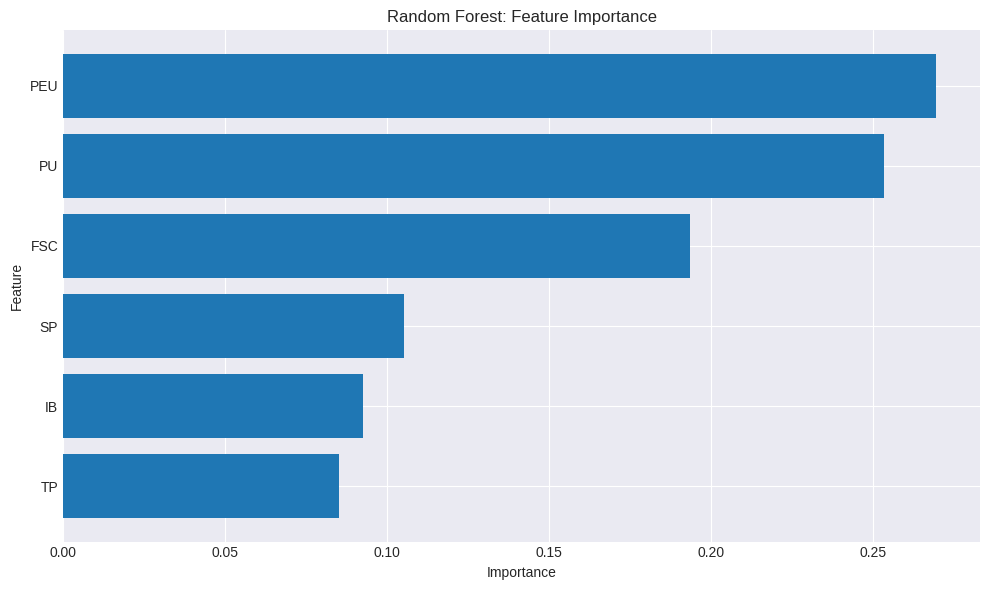

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,                  # Feature names
    "Importance": best_rf.feature_importances_   # Feature importance scores from the Random Forest model
})

feature_importance = feature_importance.sort_values(
    by="Importance",                             # Sort by feature importance
    ascending=False                              # Display the most important features first
)

plt.figure(
    figsize=(10, 6)                              # Set the figure size
)

plt.barh(
    feature_importance["Feature"],               # Feature names on the y-axis
    feature_importance["Importance"]             # Importance scores on the x-axis
)

plt.gca().invert_yaxis()                         # Display the most important feature at the top

plt.xlabel("Importance")                         # Label the x-axis
plt.ylabel("Feature")                            # Label the y-axis
plt.title("Random Forest: Feature Importance")   # Set the plot title

plt.tight_layout()                               # Adjust spacing to prevent overlapping elements
plt.show()                                       # Display the plot

### **Interpretation of Feature Importance**

The feature importance analysis indicates that **Perceived Ease of Use (PEU)** was the most influential predictor in the optimized Random Forest model, with an importance score of approximately **0.27**. This suggests that Perceived Ease of Use contributed the most to the model's predictive decisions among the predictor variables included in the analysis.

The second most influential feature was **Perceived Usefulness (PU)**, with an importance score of approximately **0.25**. Its relatively high importance, together with Perceived Ease of Use, indicates that these two perception-related constructs made the largest contributions to predicting **Actual Usage Behavior (AUB)** in the Random Forest model.

**Familiarity with Social Commerce (FSC)** had the third-highest importance at approximately **0.19**, indicating a meaningful contribution to the model's predictions, although its contribution was lower than those of Perceived Ease of Use and Perceived Usefulness. **Social Participant (SP)** followed with an importance score of approximately **0.11**, while **Interaction Behavior (IB)** and **Trust in Platform (TP)** had comparatively lower importance scores of approximately **0.09** and **0.08**, respectively.

Overall, the feature importance results show that the model relied most heavily on **Perceived Ease of Use (PEU)** and **Perceived Usefulness (PU)**, which together account for approximately **52% of the total feature importance**. **Familiarity with Social Commerce (FSC)** also made a substantial contribution, while **Social Participant (SP)**, **Interaction Behavior (IB)**, and **Trust in Platform (TP)** had smaller relative contributions. These results suggest that perceptions related to the **ease of use, usefulness, and familiarity with social commerce** were the most influential predictors of Actual Usage Behavior within the Random Forest model.

It is important to note that feature importance reflects the **relative contribution of each predictor to the Random Forest's predictive decisions** and does not by itself establish a causal relationship between the predictors and Actual Usage Behavior.

### **[9] MLP Regressor**

The Multilayer Perceptron (MLP) Regressor is a feedforward artificial neural network designed to model complex nonlinear relationships in structured tabular data. Unlike Random Forest, which learns patterns through an ensemble of decision trees, the MLP learns nonlinear relationships using interconnected neurons, hidden layers, and nonlinear activation functions. Including both models allows the study to compare two fundamentally different machine learning approaches and determine which is more suitable for predicting Actual Usage Behavior (AUB).

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV

The MLP hyperparameter search was guided by the scikit-learn implementation of MLPRegressor and established neural network practices (Pedregosa et al., 2011; scikit-learn developers, 2025). The selected search space was designed to balance model complexity with the characteristics of the present dataset, which consists of 757 observations and six predictor variables.

*   The `hidden_layer_sizes` configurations of (50), (100), and (100, 50) were selected because the optimal network architecture is problem-dependent and is typically determined experimentally rather than through a fixed rule (Goodfellow et al., 2016; scikit-learn developers, 2025). Given the relatively small dataset, small-to-moderate network architectures were preferred to provide sufficient learning capacity while reducing the risk of overfitting. Including both single- and two-hidden-layer architectures also allows the model to evaluate whether additional network depth improves predictive performance.
*   The `activation` functions ReLU and tanh were evaluated because they are among the most widely used activation functions for feedforward neural networks (Goodfellow et al., 2016). ReLU generally provides faster and more stable optimization, while tanh serves as a suitable alternative for standardized input features due to its zero-centered output (Nwankpa et al., 2018).
* The `learning_rate_init` values of 0.001 and 0.01 were selected to compare two commonly used learning rates that balance convergence speed and training stability during optimization (Goodfellow et al., 2016). Likewise, the `alpha` values of 0.0001 and 0.001 were included to evaluate different levels of L2 regularization, helping reduce overfitting while maintaining model flexibility (scikit-learn developers, 2025).

* Other hyperparameters, such as the `solver`, maximum iterations (`max_iter`), `batch size`, and `early stopping`, were kept fixed and were not included in the GridSearchCV search space. This allowed the optimization to focus on the most influential hyperparameters while keeping the search computationally manageable.

Overall, these hyperparameters provide a literature-informed search space that allows the model to evaluate different network architectures, activation functions, learning rates, and regularization strengths. Grid search with cross-validation was then used to determine which configuration produced the best predictive performance for the present dataset rather than assuming that any single configuration was universally optimal.

In [ ]:
param_grid = {
    "hidden_layer_sizes": [
        (50,),          # One hidden layer with 50 neurons
        (100,),         # One hidden layer with 100 neurons
        (100, 50)       # Two hidden layers with 100 and 50 neurons
    ],
    "activation": [
        "relu",         # Rectified Linear Unit activation function
        "tanh"          # Hyperbolic tangent activation function
    ],
    "learning_rate_init": [
        0.001,          # Initial learning rate for weight updates
        0.01
    ],
    "alpha": [
        0.0001,         # L2 regularization strength
        0.001
    ]
}

"""
Default values in scikit-learn:
  MLPRegressor(
    hidden_layer_sizes=(100,),
    activation="relu",
    learning_rate_init=0.001,
    alpha=0.0001,
    ...
)
"""

'\nDefault values in scikit-learn:\n  MLPRegressor(\n    hidden_layer_sizes=(100,),\n    activation="relu",\n    learning_rate_init=0.001,\n    alpha=0.0001,\n    ...\n)\n'

| Hyperparameter       | Description                                                                           |
| -------------------- | ------------------------------------------------------------------------------------- |
| `hidden_layer_sizes` | Defines the architecture of the neural network (number of neurons and hidden layers). |
| `activation`         | Specifies the activation function used by neurons.                                    |
| `learning_rate_init` | Determines how quickly the model updates its weights during training.                 |
| `alpha`              | L2 regularization parameter that helps reduce overfitting.                            |


The code below initializes the GridSearchCV object for the MLP Regressor using the predefined hyperparameter search space. The model is configured with a maximum of 1,000 training iterations and a fixed random seed to ensure reproducible results. Hyperparameter combinations are evaluated using the same 10-fold cross-validation strategy applied to the Random Forest model, with negative mean squared error (MSE) as the optimization metric. Parallel processing is also enabled to evaluate the search space more efficiently.

In [ ]:
grid_mlp = GridSearchCV(
    estimator=MLPRegressor(
        max_iter=1000,                 # Maximum number of training iterations
        random_state=1                 # Fixed random seed for reproducibility
    ),
    param_grid=param_grid,             # Hyperparameter combinations to evaluate
    cv=kf,                             # 10-fold cross-validation strategy
    scoring="neg_mean_squared_error",  # Optimize based on negative MSE
    n_jobs=-1                          # Use all available CPU cores for parallel processing
)

After initializing the GridSearchCV object, the model fitting process can begin. During training, GridSearchCV systematically evaluates every possible combination of the specified hyperparameters.

In [ ]:
grid_mlp.fit(
    X_train_scaled,    # Train the MLP models using the standardized training data
    y_train            # Target values corresponding to the training data
)

GridSearchCV(cv=KFold(n_splits=10, random_state=1, shuffle=True),
             estimator=MLPRegressor(max_iter=1000, random_state=1), n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001],
                         'hidden_layer_sizes': [(50,), (100,), (100, 50)],
                         'learning_rate_init': [0.001, 0.01]},
             scoring='neg_mean_squared_error')

Display the hyperparameter combination that achieved the best average performance during the GridSearchCV search, then report the corresponding cross-validation Mean Squared Error (MSE). Since GridSearchCV maximizes the negative MSE score, the value is multiplied by **-1** to obtain the actual MSE, where lower values indicate better predictive performance.

In [ ]:
print("===== Best Hyperparameters =====")
print(
    grid_mlp.best_params_    # Display the hyperparameter combination with the best cross-validation performance
)

print("\nBest Cross-Validation MSE:")
print(
    -grid_mlp.best_score_    # Convert the negative MSE back to a positive Mean Squared Error
)

===== Best Hyperparameters =====
{'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}

Best Cross-Validation MSE:
0.15553215745375432


The results show that GridSearchCV selected a network with a **single hidden layer containing 100 neurons**, using the **tanh** activation function, a **learning rate of 0.001**, and an **L2 regularization strength (alpha) of 0.001**. This suggests that, among the evaluated configurations, a relatively simple network architecture was sufficient for the dataset while providing the best balance between learning capacity and generalization. The selection of **tanh** indicates that it performed better than ReLU for the standardized input features, while the smaller learning rate and regularization value provided stable training and helped reduce overfitting. This configuration achieved the lowest average cross-validation MSE of **0.1555**, making it the optimal MLP model for the subsequent evaluation.

The optimized MLP model is retrieved using `best_estimator_`, which returns the best hyperparameter combination result from earlier. The model is then used to generate predicted Actual Usage Behavior (AUB) values for the standardized test data. Because the test set was not used during model training or hyperparameter tuning, these predictions provide an unbiased basis for evaluating the model's predictive performance.

In [ ]:
best_mlp = grid_mlp.best_estimator_    # Retrieve the best-performing MLP model

mlp_pred = best_mlp.predict(
    X_test_scaled                      # Generate predictions for the standardized test data
)

We then evaluate the predictive performance of the optimized MLP model on the test dataset using four regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). These metrics provide a comprehensive assessment of prediction accuracy and are the same evaluation measures used for the Random Forest model, allowing a fair comparison between the two approaches.

In [ ]:
mlp_mae = mean_absolute_error(y_test, mlp_pred)   # Compute Mean Absolute Error (MAE)
mlp_mse = mean_squared_error(y_test, mlp_pred)    # Compute Mean Squared Error (MSE)
mlp_rmse = np.sqrt(mlp_mse)                       # Compute Root Mean Squared Error (RMSE)
mlp_r2 = r2_score(y_test, mlp_pred)               # Compute the coefficient of determination (R²)

print("===== Tuned MLP =====")

print("\nEvaluation on Test Set")
print(f"MAE : {mlp_mae:.4f}")
print(f"MSE : {mlp_mse:.4f}")
print(f"RMSE: {mlp_rmse:.4f}")
print(f"R²  : {mlp_r2:.4f}")

===== Tuned MLP =====

Evaluation on Test Set
MAE : 0.2627
MSE : 0.1526
RMSE: 0.3906
R²  : 0.7097


#### Interpretation of Metrics

The optimized MLP model achieved a **Mean Absolute Error (MAE)** of **0.2627**, indicating that its predictions differed from the actual AUB values by an average of approximately **0.26** on the five-point Likert scale. This relatively small error suggests that the model is generally able to predict respondents' Actual Usage Behavior with good accuracy.

The model also obtained a **Mean Squared Error (MSE)** of **0.1526** and a **Root Mean Squared Error (RMSE)** of **0.3906**. Since RMSE is expressed in the same unit as the target variable, it indicates that the model's predictions typically deviate from the actual AUB values by less than **0.4 points**. The difference between the MAE and RMSE is also relatively small, suggesting that while some larger prediction errors exist, they are not frequent enough to substantially affect the model's overall performance.

Furthermore, the optimized MLP achieved an **R² score of 0.7097**, indicating that approximately **71.0%** of the variation in Actual Usage Behavior can be explained by the predictor variables included in the model. This suggests that the behavioral and perception constructs collectively provide strong predictive information for estimating AUB.

In conclusion, the evaluation metrics indicate that the tuned MLP model produces accurate and reliable predictions while maintaining good generalization on unseen data. Although some prediction error remains, the relatively low error values and high coefficient of determination demonstrate that the model effectively captures the relationship between the behavioral constructs and Actual Usage Behavior.

To better visualize the predictive performance of the optimized MLP model, a scatter plot of the actual and predicted AUB values is generated. The dashed red line represents perfect predictions, allowing the agreement between the actual and predicted values to be visually assessed.

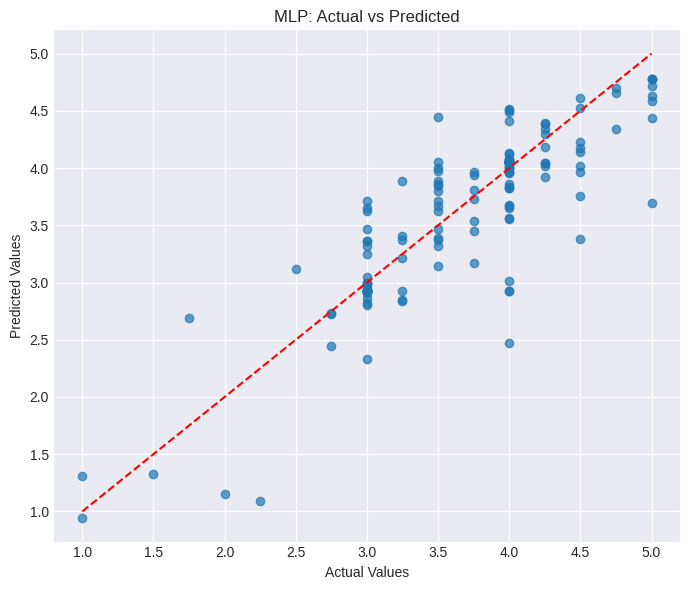

In [ ]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(7, 6)                  # Set the figure size
)

plt.scatter(
    y_test,                         # Actual target values
    mlp_pred,                       # Predicted target values
    alpha=0.7                       # Set point transparency
)

plt.plot(
    [y_test.min(), y_test.max()],   # Minimum and maximum actual values (x-axis)
    [y_test.min(), y_test.max()],   # Minimum and maximum actual values (y-axis)
    'r--'                           # Reference line representing perfect predictions
)

plt.xlabel("Actual Values")         # Label the x-axis
plt.ylabel("Predicted Values")      # Label the y-axis
plt.title("MLP: Actual vs Predicted")  # Set the plot title

plt.grid(True)                      # Display gridlines

plt.tight_layout()                  # Adjust spacing to prevent overlapping elements
plt.show()                          # Display the plot

#### Interpretation of Scatter Plot

Overall, most observations are distributed close to this reference line, indicating that the model is able to predict Actual Usage Behavior with reasonably good accuracy.

The highest concentration of points occurs between AUB values of approximately **3.0 and 4.5**, which corresponds to the range where most respondents are located. Within this region, the predicted values generally follow the upward trend of the actual values, suggesting that the model successfully captures the underlying relationship between the behavioral constructs and Actual Usage Behavior.

Although the predictions generally align with the reference line, some deviations are evident. Several observations fall above the line, indicating that the model overestimated the actual AUB values, while others fall below the line, indicating underestimation. These deviations become slightly more noticeable toward the higher AUB values (around **4.0–5.0**), where a few predictions are farther from the reference line. However, no systematic pattern of overprediction or underprediction is observed, suggesting that the prediction errors are relatively balanced rather than consistently biased in one direction.

The spread of the points around the reference line is relatively small compared with the overall range of the target variable, indicating that the prediction errors are generally moderate. This visual assessment is consistent with the numerical evaluation metrics, particularly the **RMSE of 0.3906** and the **R² value of 0.7097**, which indicate that the optimized MLP model explains approximately **71%** of the variation in Actual Usage Behavior while maintaining relatively low prediction error on the unseen test data. Overall, the scatter plot supports the conclusion that the tuned MLP model generalizes well and provides reliable predictions for this dataset.

To further evaluate the predictive performance of the optimized MLP model, a residual plot is generated. The plot shows the residuals (actual − predicted) against the predicted values. Ideally, the residuals should be randomly scattered around the zero reference line, indicating that the prediction errors are random rather than systematic.

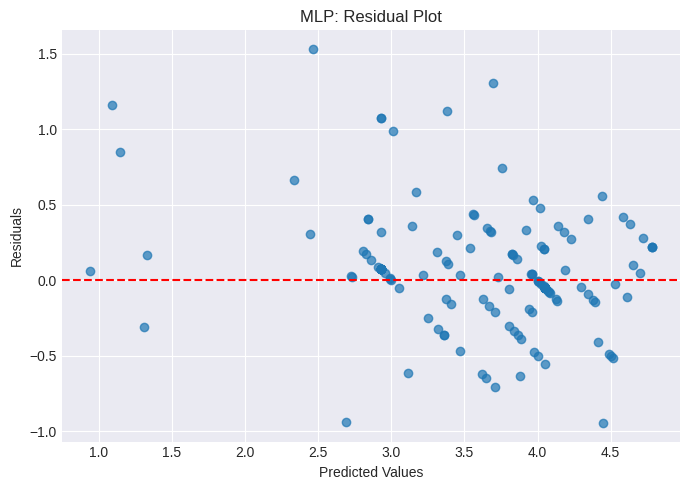

In [ ]:
mlp_residuals = y_test - mlp_pred    # Compute the residuals (actual - predicted)

plt.figure(
    figsize=(7, 5)                   # Set the figure size
)

plt.scatter(
    mlp_pred,                        # Predicted target values
    mlp_residuals,                   # Residual values
    alpha=0.7                        # Set point transparency
)

plt.axhline(
    y=0,                             # Reference line indicating zero residual
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")       # Label the x-axis
plt.ylabel("Residuals")              # Label the y-axis
plt.title("MLP: Residual Plot")      # Set the plot title

plt.grid(True)                       # Display gridlines

plt.tight_layout()                   # Adjust spacing to prevent overlapping elements
plt.show()                           # Display the plot

#### Interpretation of Residual Plot

The residual plot shows that the prediction errors are generally scattered around the zero reference line, indicating that the optimized MLP model does not consistently overestimate or underestimate Actual Usage Behavior. Most residuals are relatively close to zero, suggesting that the model produces reasonably accurate predictions across the test dataset.

No clear trend, curved pattern, or funnel-shaped distribution is observed, indicating that the residuals are randomly distributed rather than systematic. This suggests that the model has successfully captured most of the underlying relationship between the predictor variables and Actual Usage Behavior. Although a few larger residuals are present, particularly for some lower predicted values, these appear to be isolated observations rather than evidence of model bias.

The slightly larger residuals observed for some lower predicted AUB values may be related to the relatively small number of respondents with low engagement levels in the dataset. Because fewer training examples are available in this range, the model has less information from which to learn these patterns, resulting in slightly larger prediction errors for some observations.

Overall, the residual plot supports the evaluation metrics obtained earlier, indicating that the optimized MLP model provides stable predictions and generalizes well to unseen data.

### [10] Comparison of Results between Random Forest and Multi-Layer Perceptron

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "MLP"
    ],
    "MAE": [
        rf_mae,     # Mean Absolute Error of the Random Forest model
        mlp_mae     # Mean Absolute Error of the MLP model
    ],
    "MSE": [
        rf_mse,     # Mean Squared Error of the Random Forest model
        mlp_mse     # Mean Squared Error of the MLP model
    ],
    "RMSE": [
        rf_rmse,    # Root Mean Squared Error of the Random Forest model
        mlp_rmse    # Root Mean Squared Error of the MLP model
    ],
    "R²": [
        rf_r2,      # Coefficient of determination of the Random Forest model
        mlp_r2      # Coefficient of determination of the MLP model
    ]
})

comparison    # Display the evaluation metrics of both models for comparison

,Model,MAE,MSE,RMSE,R²
0,Random Forest,0.230437,0.130369,0.361067,0.752002
1,MLP,0.262666,0.152595,0.390634,0.709723


Based on the evaluation metrics summarized in the table above, the tuned Random Forest model outperformed the tuned MLP model across every metric considered. Random Forest achieved a lower **MAE** (0.2304 vs. 0.2627), lower **MSE** (0.1304 vs. 0.1526), and lower **RMSE** (0.3611 vs. 0.3906), indicating that its predictions were, on average, closer to the actual AUB values than those of the MLP. Random Forest also achieved a higher **R²** score (0.7520 vs. 0.7097), meaning it explained approximately **75.2%** of the variance in Actual Usage Behavior compared to **71.0%** for the MLP, which is a difference of roughly 4 percentage points.

Although Random Forest performed better on every metric, the gap between the two models is relatively modest. Both models achieved R² scores above 0.70 and RMSE values below 0.4 on a five-point Likert scale, indicating that both approaches were able to capture the underlying relationship between the perception/behavioral constructs and Actual Usage Behavior reasonably well. This is not entirely surprising given the size of the dataset (757 observations) and the modest number of predictors (six constructs): tree-based ensemble methods such as Random Forest are generally well-suited to smaller, low-dimensional tabular datasets, whereas neural network models like MLP typically benefit from larger sample sizes and more complex feature interactions to fully leverage their flexibility.

Beyond predictive accuracy, Random Forest also offers a practical advantage in this context as it provides directly interpretable feature importance scores (as shown in the earlier analysis), allowing the relative contribution of PU, PEU, FSC, SP, TP, and IB to be examined. The MLP, in contrast, functions largely as a black box, which limits its usefulness for explaining why certain constructs matter more than others. Taken together, these results suggest that Random Forest is the more suitable model for this dataset, both in terms of predictive performance and interpretability.


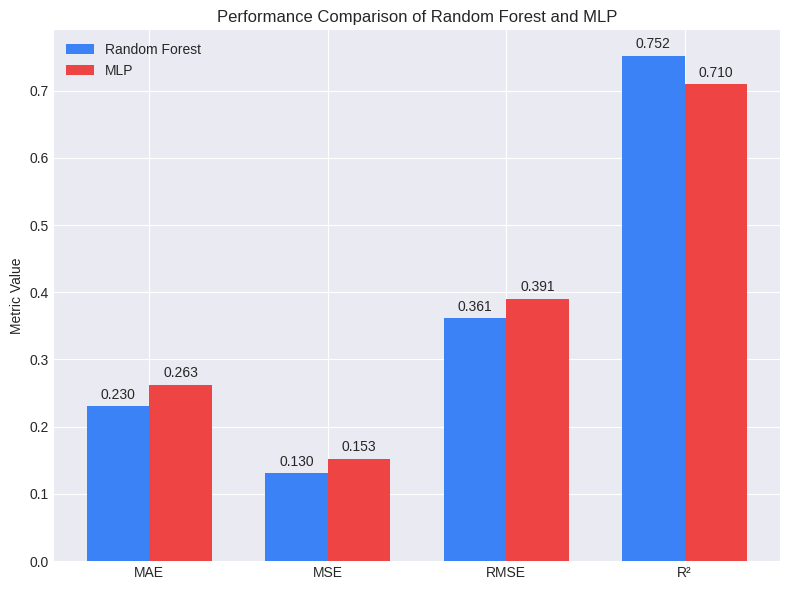

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["MAE", "MSE", "RMSE", "R²"]    # Evaluation metrics to compare

x = np.arange(len(metrics))               # Generate x-axis positions
width = 0.35                              # Set the width of each bar

plt.figure(
    figsize=(8, 6)                        # Set the figure size
)

rf_bars = plt.bar(
    x - width / 2,                        # Position bars for the Random Forest model
    comparison.loc[0, metrics],           # Random Forest metric values
    width,
    label="Random Forest",
    color="#3B82F6",                      # Blue
)

mlp_bars = plt.bar(
    x + width / 2,                        # Position bars for the MLP model
    comparison.loc[1, metrics],           # MLP metric values
    width,
    label="MLP",
    color="#EF4444",                      # Red
)

plt.bar_label(
    rf_bars,                              # Display Random Forest metric values
    fmt="%.3f",
    padding=3
)

plt.bar_label(
    mlp_bars,                             # Display MLP metric values
    fmt="%.3f",
    padding=3
)

plt.xticks(
    x,
    metrics                               # Set x-axis labels
)

plt.ylabel("Metric Value")                # Label the y-axis
plt.title("Performance Comparison of Random Forest and MLP")  # Set the plot title

plt.legend()                              # Display the legend

plt.tight_layout()                        # Adjust spacing to prevent overlapping elements
plt.show()                                # Display the plot

#### Interpretation of Comparison Chart

The bar chart clearly shows that Random Forest (blue) outperforms MLP (red) in R² and has lower values for MAE, MSE, and RMSE. While the differences in the error metrics are small, the gap in R² is more noticeable. This indicates that Random Forest has a slight but consistent advantage over MLP for predicting Actual Usage Behavior, making both models suitable choices.


### **[11] Recommendation**

Based on the results of this study, the following recommendations are proposed:

**Model Selection.** Given its stronger and more consistent performance across all four evaluation metrics, along with its built-in interpretability through feature importance scores, the Random Forest model is recommended as the preferred model for predicting Actual Usage Behavior (AUB) in this context. The MLP remains a reasonable alternative, particularly if future research includes a larger dataset or more complex, non-linear feature interactions that could better leverage its flexibility.

**Platform Design Implications.** The feature importance results indicate that Perceived Ease of Use (PEU) and Perceived Usefulness (PU) were the strongest predictors of Actual Usage Behavior, together accounting for roughly half of the model's total feature importance. This suggests that social commerce platforms targeting Generation Z university students in Vietnam should prioritize improving the ease of navigation, usability, and perceived functional value of their platforms, as these factors appear to have the greatest influence on driving actual engagement, more so than trust or social participation alone.

**Future Research.** Because the dataset was restricted to a specific age range (18–27) and geographic context (Vietnam), the findings should not be generalized beyond this population. Future studies could extend this work by (1) collecting a larger and more diverse sample to improve model generalizability and give the MLP more data to learn from, (2) incorporating additional predictor variables (e.g., platform type, purchase frequency, or specific product categories), and (3) testing additional algorithms.

Expanding the dataset in both directions, more observations and more predictors, would give both models more information to learn from during training. A larger sample would especially benefit the MLP, since neural networks are generally data-hungry and tend to improve substantially with more training examples, whereas Random Forest already performs reasonably well even on a comparatively small dataset such as this one. Likewise, adding predictors beyond the six psychological/behavioral constructs used here, such as platform type, purchase frequency, or purchase amount, would provide the models with a more complete picture of the factors driving Actual Usage Behavior, rather than relying solely on attitudinal and perception-based variables. Together, these additions would likely improve both models' predictive performance and their ability to generalize to the broader population.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press. https://www.deeplearningbook.org/

Nwankpa, C., Ijomah, W., Gachagan, A., & Marshall, S. (2018). *Activation functions: Comparison of trends in practice and research for deep learning*. arXiv. https://arxiv.org/abs/1811.03378

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830. https://jmlr.org/papers/v12/pedregosa11a.html

Probst, P., Wright, M. N., & Boulesteix, A.-L. (2019). Hyperparameters and tuning strategies for random forest. WIREs Data Mining and Knowledge Discovery, 9(3), e1301. https://doi.org/10.1002/widm.1301

scikit-learn developers. (2025). *MLPRegressor*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html

** will add mine later